# Wetstock EDA — Birleşik Master Notebook

Tüm keşifsel analiz adımları **tek dosyada**, bölüm bölüm.

| Bölüm | Konu |
|-------|------|
| 1–10 | Şema → tutarlılık → null → tank → alarm → envanter → satış → manifold → anomali → derin EDA |

> Grafikler `eda/output/figures/<bölüm>/` altına kaydedilir.
> `data/ground_truth/` bu aşamada **kullanılmaz**.

---

In [1]:
# ============================================================
# KURULUM — tüm bölümler bu ortamı paylaşır
# ============================================================
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import (
    load_all, filter_tank, merge_ue1t_inventory, summary_table, DATA_DIR,
)
from utils.validation import run_all_checks, check_tx_to_ue1t
from utils.plots import setup_style, save_fig, set_section
from utils.paths import figures_dir

setup_style()
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('Veri klasörü:', DATA_DIR)
print('Grafik çıktısı:', figures_dir())
dfs = load_all()
ue = dfs['ue1t_30min']
tanks = dfs['tanks']
inv = dfs['inventory_30min']
daily = dfs['daily']
tx = dfs['transactions']
deliv = dfs['deliveries']
mapping = dfs['mapping']
print('Yüklendi:', {k: v.shape for k, v in dfs.items()})

Veri klasörü: /Users/mangtay/Desktop/Staj/data
Grafik çıktısı: /Users/mangtay/Desktop/Staj/eda/output/figures/genel


Yüklendi: {'stations': (8, 3), 'tanks': (32, 11), 'mapping': (81, 7), 'transactions': (231874, 11), 'deliveries': (1109, 12), 'inventory_30min': (138194, 11), 'ue1t_30min': (138194, 16), 'daily': (2880, 13)}


---
## BÖLÜM 1 — Veri şeması ve özet

Kaynak: `notebooks/01_veri_semasi_ve_ozet.ipynb`


In [2]:
# Tablo özeti
ozet = summary_table(dfs)
display(ozet)


,tablo,satir,kolon,null_kolon_sayisi,toplam_null,null_detay
0,stations,8,3,0,0,{}
1,tanks,32,11,0,0,{}
2,mapping,81,7,1,2,{'manifold_grup_no': 2}
3,transactions,231874,11,3,3938,"{'tank_no': 2548, 'litre': 463, 'birim_fiyat':..."
4,deliveries,1109,12,3,367,"{'dolum_oncesi_hacim': 88, 'sicaklik': 109, 'm..."
5,inventory_30min,138194,11,5,852,"{'urun_miktari_net': 240, 'su_seviyesi_cm': 48..."
6,ue1t_30min,138194,16,2,654,"{'sicaklik': 240, 'baslangic_seviyesi_cm': 414}"
7,daily,2880,13,0,0,{}


In [3]:
# Her tablonun kolonları
for name, df in dfs.items():
    print('=' * 60)
    print(f'{name}: {df.shape[0]:,} satır x {df.shape[1]} kolon')
    print('Kolonlar:', list(df.columns))
    print(df.dtypes)
    print()


stations: 8 satır x 3 kolon
Kolonlar: ['istasyon_kodu', 'bolge', 'tank_sayisi']
istasyon_kodu    object
bolge            object
tank_sayisi       int64
dtype: object

tanks: 32 satır x 11 kolon
Kolonlar: ['istasyon_kodu', 'tank_no', 'urun_no', 'akaryakit_turu', 'kapasite', 'tank_capi', 'tank_uzunlugu', 'bolmeli', 'bolme_grup_no', 'is_manifold', 'manifold_grup_no']
istasyon_kodu       object
tank_no              int64
urun_no              int64
akaryakit_turu      object
kapasite             int64
tank_capi            int64
tank_uzunlugu        int64
bolmeli              int64
bolme_grup_no        int64
is_manifold          int64
manifold_grup_no     int64
dtype: object

mapping: 81 satır x 7 kolon
Kolonlar: ['istasyon_kodu', 'pompa_no', 'tabanca_no', 'tank_no', 'urun_no', 'akaryakit_turu', 'manifold_grup_no']
istasyon_kodu        object
pompa_no              int64
tabanca_no            int64
tank_no               int64
urun_no               int64
akaryakit_turu       object
manifold_gr

In [4]:
# İstasyon × tank matrisi
stations = dfs['stations']
tanks = dfs['tanks']
print(stations.to_string(index=False))
print()
print('Tank sayısı istasyon başına:')
print(tanks.groupby('istasyon_kodu').size().to_string())


istasyon_kodu        bolge  tank_sayisi
      IST_001      Marmara            5
      IST_002          Ege            5
      IST_003      Marmara            3
      IST_004   Ic Anadolu            5
      IST_005   Ic Anadolu            3
      IST_006      Akdeniz            4
      IST_007    Karadeniz            4
      IST_008 Dogu Anadolu            3

Tank sayısı istasyon başına:
istasyon_kodu
IST_001    5
IST_002    5
IST_003    3
IST_004    5
IST_005    3
IST_006    4
IST_007    4
IST_008    3


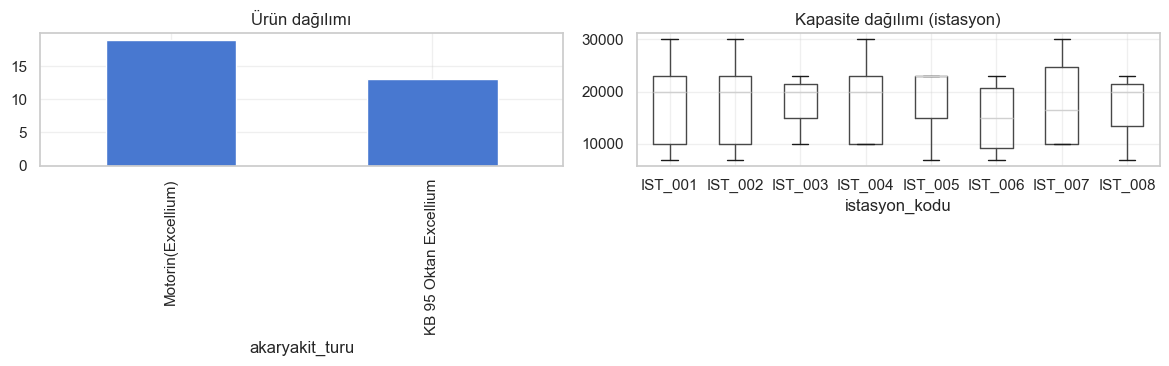

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/01_schema/01_schema_01.png')

In [5]:
# Ürün ve kapasite dağılımı
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tanks['akaryakit_turu'].value_counts().plot(kind='bar', ax=axes[0], title='Ürün dağılımı')
tanks.boxplot(column='kapasite', by='istasyon_kodu', ax=axes[1])
axes[1].set_title('Kapasite dağılımı (istasyon)')
plt.suptitle('')
plt.tight_layout()
set_section('01_schema')
save_fig(name='01_schema_01')


In [6]:
# Tarih aralığı
daily = dfs['daily']
tx = dfs['transactions']
print('Daily  :', daily.tarih.min(), '→', daily.tarih.max(), f'({daily.tarih.nunique()} gün)')
print('TX     :', tx.satis_zamani.min(), '→', tx.satis_zamani.max())
print('Beklenen daily satır (32 tank × 90 gün):', 32 * 90)
print('Gerçek daily satır:', len(daily))


Daily  : 2026-01-01 00:00:00 → 2026-03-31 00:00:00 (90 gün)
TX     : 2026-01-01 00:01:19 → 2026-03-31 23:59:31
Beklenen daily satır (32 tank × 90 gün): 2880
Gerçek daily satır: 2880


In [7]:
# Granülarite tablosu
gran = pd.DataFrame([
    ['transactions', 'tekil satış', 'değişken (~100+/gün/tank)'],
    ['ue1t_30min', '30 dakika', '48/gün/tank'],
    ['inventory_30min', '30 dakika', '48/gün/tank'],
    ['daily', 'günlük', '1/gün/tank'],
    ['deliveries', 'olay bazlı', 'dolum olduğunda'],
], columns=['tablo', 'granülarite', 'beklenen'])
display(gran)


,tablo,granülarite,beklenen
0,transactions,tekil satış,değişken (~100+/gün/tank)
1,ue1t_30min,30 dakika,48/gün/tank
2,inventory_30min,30 dakika,48/gün/tank
3,daily,günlük,1/gün/tank
4,deliveries,olay bazlı,dolum olduğunda


## Sonuç

- Veri **yıldız şeması**: `istasyon_kodu + tank_no` ile tüm tablolar birbirine bağlanır.
- Sonraki notebook: katman tutarlılığı doğrulaması (`02_katman_tutarliligi.ipynb`).

---
## BÖLÜM 2 — Katman tutarlılığı

Kaynak: `notebooks/02_katman_tutarliligi.ipynb`


In [8]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all
from utils.validation import run_all_checks, check_ue1t_balance
from utils.plots import setup_style

setup_style()
dfs = load_all()
checks = run_all_checks(dfs)
checks['summary']


{'mutabakat_max_abs': 3.637978807091713e-12,
 'sureklilik_gt_001': 0,
 'tx_ue1t_gt_001': 2941,
 'daily_satis_max_fark': 7.275957614183426e-12,
 'delivery_fark_gt_001': 4}

Mutabakat residual istatistikleri:
count   138,194.00
mean          0.00
std           0.00
min          -0.00
25%           0.00
50%           0.00
75%           0.00
max           0.00
Name: mutabakat_residual, dtype: float64
Max abs: 3.637978807091713e-12


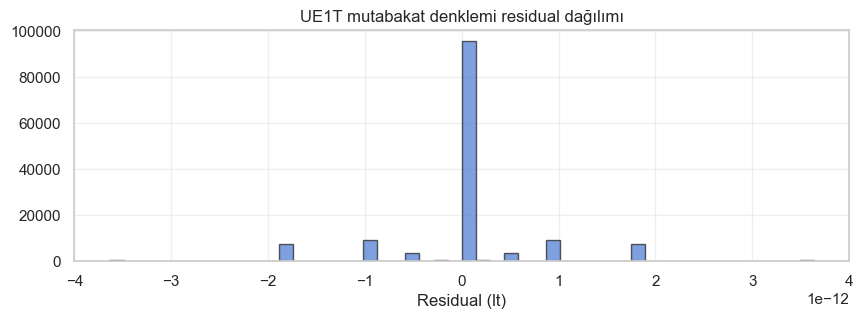

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/02_validation/02_validation_01.png')

In [9]:
# 1) UE1T mutabakat denklemi
ue1t_bal = checks['ue1t_balance']
print('Mutabakat residual istatistikleri:')
print(ue1t_bal['mutabakat_residual'].describe())
print('Max abs:', ue1t_bal['mutabakat_residual'].abs().max())

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(ue1t_bal['mutabakat_residual'], bins=50, edgecolor='k', alpha=0.7)
ax.set_xlabel('Residual (lt)')
ax.set_title('UE1T mutabakat denklemi residual dağılımı')
set_section('02_validation')
save_fig(name='02_validation_01')


In [10]:
# 2) Süreklilik — kesinti dışı beklenen ~0
cont = checks['continuity']
big = cont[cont['sureklilik_fark'].abs() > 0.01]
print(f'Süreklilik |fark|>0.01 satır: {len(big)} (kesinti/boşluk normal)')
if len(big):
    display(big[['istasyon_kodu','tank_no','saat_1','onceki_son','donem_basi_stok','sureklilik_fark']].head(10))


Süreklilik |fark|>0.01 satır: 0 (kesinti/boşluk normal)


TX vs UE1T uyuşmayan dönem: 2941
Unmapped satış litre toplamı: 93008.1


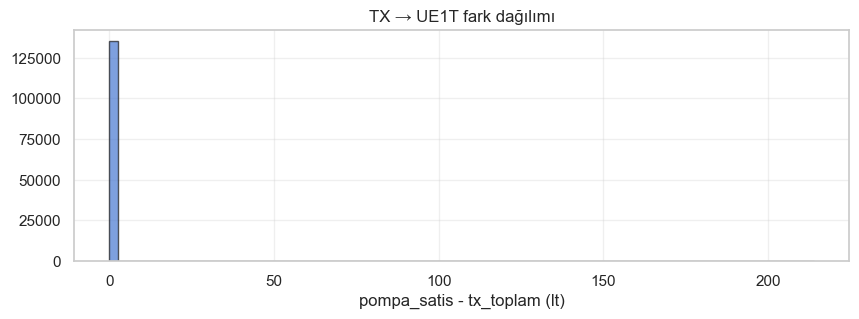

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/02_validation/02_validation_02.png')

In [11]:
# 3) TX → UE1T
txu = checks['tx_to_ue1t']
mismatch = txu[txu['tx_ue1t_fark'].abs() > 0.01]
print(f'TX vs UE1T uyuşmayan dönem: {len(mismatch)}')
print(f'Unmapped satış litre toplamı: {dfs["transactions"].loc[dfs["transactions"].tank_no.isna(), "litre"].sum():.1f}')

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(txu['tx_ue1t_fark'], bins=80, edgecolor='k', alpha=0.7)
ax.set_xlabel('pompa_satis - tx_toplam (lt)')
ax.set_title('TX → UE1T fark dağılımı')
set_section('02_validation')
save_fig(name='02_validation_02')


In [12]:
# 4) UE1T → Daily
ud = checks['ue1t_to_daily']
for col in ['satis_fark','dolum_fark','acilis_fark','kapanis_fark']:
    print(f'{col}: max abs = {ud[col].abs().max():.6f}')

alarm_gun = ud[ud['satis_fark'].abs() > 0.01]
if len(alarm_gun):
    display(alarm_gun.head())


satis_fark: max abs = 0.000000
dolum_fark: max abs = 0.000000
acilis_fark: max abs = 0.000000
kapanis_fark: max abs = 0.000000


In [13]:
# 5) Deliveries → Daily
dd = checks['deliveries_to_daily']
bad = dd[dd['delivery_fark'].abs() > 0.01]
print(f'Delivery vs daily fark >0.01 gün: {len(bad)}')
print('(Gün sonu dolum kayması olabilir — EDA bulgusu)')
if len(bad):
    display(bad[['tarih','istasyon_kodu','tank_no','dolum','dolum_net','delivery_fark']].head(10))


Delivery vs daily fark >0.01 gün: 4
(Gün sonu dolum kayması olabilir — EDA bulgusu)


,tarih,istasyon_kodu,tank_no,dolum,dolum_net,delivery_fark
2444,2026-01-15,IST_007,3,0.00,"4,325.05","-4,325.05"
2445,2026-01-16,IST_007,3,"4,325.05",0.00,"4,325.05"
2534,2026-01-15,IST_007,4,0.00,"4,532.83","-4,532.83"
2535,2026-01-16,IST_007,4,"4,532.83",0.00,"4,532.83"


In [14]:
# Tek tank, tek gün derin doğrulama
IST, TANK, GUN = 'IST_001', 1, pd.Timestamp('2026-01-01')
u = dfs['ue1t_30min'][(dfs['ue1t_30min'].istasyon_kodu==IST)&(dfs['ue1t_30min'].tank_no==TANK)]
u = u[u.saat_1.dt.normalize()==GUN]
t = dfs['transactions'][(dfs['transactions'].istasyon_kodu==IST)&(dfs['transactions'].tank_no==TANK)]
t = t[t.satis_zamani.dt.normalize()==GUN]
d = dfs['daily'][(dfs['daily'].istasyon_kodu==IST)&(dfs['daily'].tank_no==TANK)&(dfs['daily'].tarih==GUN)]

print('=== IST_001 Tank 1 — 2026-01-01 ===')
print(f'daily.satis      = {d.satis.iloc[0]:.2f}')
print(f'ue1t toplam      = {u.pompa_satis.sum():.2f}')
print(f'tx toplam        = {t.litre.sum():.2f}')
print(f'daily.acilis     = {d.acilis.iloc[0]:.2f}  | ue1t ilk = {u.donem_basi_stok.iloc[0]:.2f}')
print(f'daily.kapanis    = {d.kapanis.iloc[0]:.2f}  | ue1t son = {u.donem_sonu_stok.iloc[-1]:.2f}')


=== IST_001 Tank 1 — 2026-01-01 ===
daily.satis      = 4069.95
ue1t toplam      = 4069.95
tx toplam        = 4069.95
daily.acilis     = 16846.98  | ue1t ilk = 16846.98
daily.kapanis    = 12779.79  | ue1t son = 12779.79


## Sonuç

Katmanlar tutarlı. TX↔UE1T farkları çoğunlukla **unmapped satış** (`tank_no` null) kaynaklı.

Sonraki: null analizi (`03_null_ve_eksik_veri.ipynb`).

---
## BÖLÜM 3 — Null ve eksik veri

Kaynak: `notebooks/03_null_ve_eksik_veri.ipynb`


In [15]:
# Genel null matrisi
null_rows = []
for name, df in dfs.items():
    for col in df.columns:
        n = df[col].isna().sum()
        if n:
            null_rows.append({'tablo': name, 'kolon': col, 'null_sayisi': n,
                              'oran_pct': round(100*n/len(df), 3)})
null_df = pd.DataFrame(null_rows).sort_values('null_sayisi', ascending=False)
display(null_df)


,tablo,kolon,null_sayisi,oran_pct
1,transactions,tank_no,2548,1.10
3,transactions,birim_fiyat,927,0.40
2,transactions,litre,463,0.20
13,ue1t_30min,baslangic_seviyesi_cm,414,0.30
11,inventory_30min,merkeze_gelis_tarihi,276,0.20
7,inventory_30min,urun_miktari_net,240,0.17
10,inventory_30min,sicaklik,240,0.17
12,ue1t_30min,sicaklik,240,0.17
6,deliveries,merkeze_gelis_tarihi,170,15.33
5,deliveries,sicaklik,109,9.83


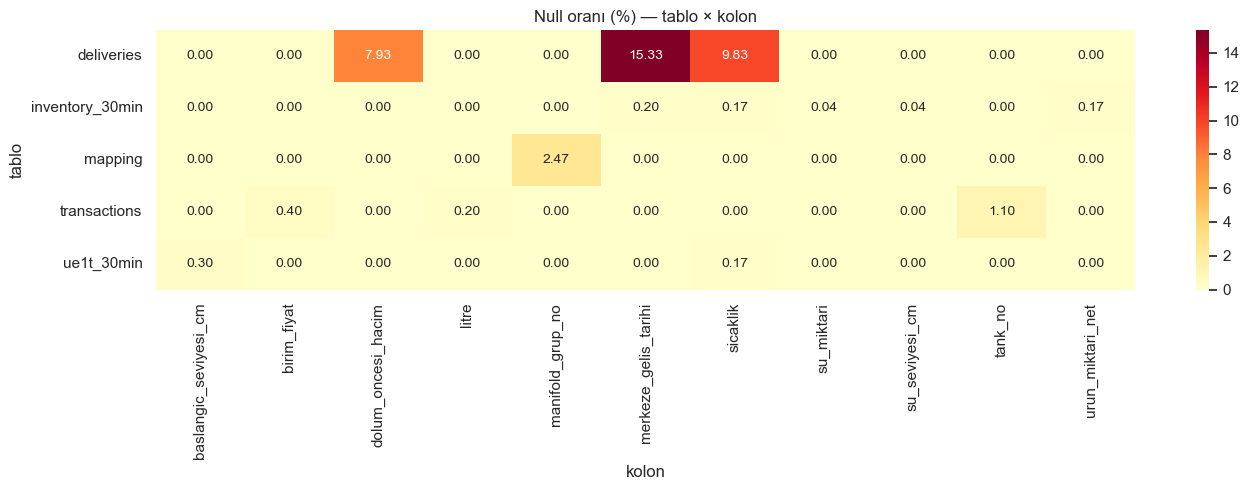

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/03_nulls/03_nulls_01.png')

In [16]:
# Heatmap — tablo × kolon null oranı
pivot = null_df.pivot_table(index='tablo', columns='kolon', values='oran_pct', fill_value=0)
plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Null oranı (%) — tablo × kolon')
plt.tight_layout()
set_section('03_nulls')
save_fig(name='03_nulls_01')


In [17]:
# transactions.tank_no null — istasyon kırılımı
tx = dfs['transactions']
unmapped = tx[tx['tank_no'].isna()]
print('Unmapped satış:', len(unmapped), f'({100*len(unmapped)/len(tx):.2f}%)')
print(unmapped.groupby('istasyon_kodu').size().sort_values(ascending=False))


Unmapped satış: 2548 (1.10%)
istasyon_kodu
IST_004    418
IST_001    382
IST_002    370
IST_007    337
IST_006    330
IST_003    265
IST_008    224
IST_005    222
dtype: int64


In [18]:
# sicaklik null — tank×gün kümesi mi?
ue1t = dfs['ue1t_30min']
inv = dfs['inventory_30min']
for name, df, col in [('ue1t','ue1t_30min','sicaklik'), ('inventory','inventory_30min','sicaklik')]:
    d = dfs[name.replace('inventory','inventory_30min') if name=='inventory' else 'ue1t_30min']
    sn = d[d['sicaklik'].isna()].copy()
    if len(sn):
        sn['gun'] = sn['saat_1' if 'saat_1' in sn.columns else 'envanter_tarihi'].dt.date
        print(f'\n{name} sicaklik null: {len(sn)} satır')
        print('Tank-gün kümesi (ilk 10):')
        print(sn.groupby(['istasyon_kodu','tank_no','gun']).size().head(10))



ue1t sicaklik null: 240 satır
Tank-gün kümesi (ilk 10):
istasyon_kodu  tank_no  gun       
IST_002        1        2026-03-19    48
               4        2026-01-14    48
IST_003        1        2026-01-12    48
               3        2026-01-18    48
IST_008        2        2026-03-12    48
dtype: int64

inventory sicaklik null: 240 satır
Tank-gün kümesi (ilk 10):
istasyon_kodu  tank_no  gun       
IST_002        1        2026-03-19    47
                        2026-03-20     1
               4        2026-01-14    47
                        2026-01-15     1
IST_003        1        2026-01-12    47
                        2026-01-13     1
               3        2026-01-18    47
                        2026-01-19     1
IST_008        2        2026-03-12    47
                        2026-03-13     1
dtype: int64


In [19]:
# merkeze_gelis gecikmesi — router arızası imzası
inv = dfs['inventory_30min'].copy()
inv['gecikme_dk'] = (inv['merkeze_gelis_tarihi'] - inv['envanter_tarihi']).dt.total_seconds() / 60
print('Gecikme istatistikleri (dk):')
print(inv['gecikme_dk'].describe())

# En yüksek gecikmeli istasyon-gün
inv['tarih'] = inv['envanter_tarihi'].dt.normalize()
lag_day = inv.groupby(['istasyon_kodu','tarih'])['gecikme_dk'].median().reset_index()
top = lag_day.nlargest(5, 'gecikme_dk')
print('\nEn yüksek medyan gecikme (istasyon-gün):')
display(top)


Gecikme istatistikleri (dk):
count   137,918.00
mean          7.10
std          35.19
min           1.00
25%           3.97
50%           6.00
75%           8.03
max       1,795.79
Name: gecikme_dk, dtype: float64

En yüksek medyan gecikme (istasyon-gün):


,istasyon_kodu,tarih,gecikme_dk
200,IST_003,2026-01-19,993.59
454,IST_005,2026-04-01,8.00
636,IST_007,2026-04-01,7.67
235,IST_003,2026-02-23,7.00
298,IST_004,2026-01-26,6.79


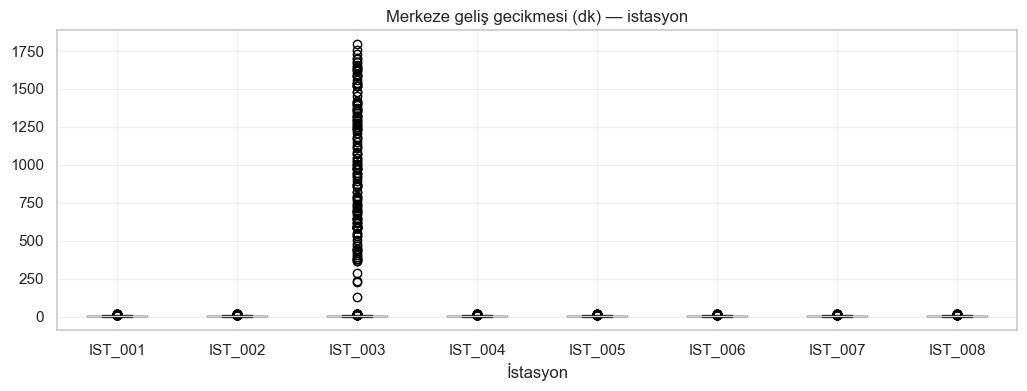

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/03_nulls/03_nulls_02.png')

In [20]:
fig, ax = plt.subplots(figsize=(12, 4))
inv.boxplot(column='gecikme_dk', by='istasyon_kodu', ax=ax)
ax.set_title('Merkeze geliş gecikmesi (dk) — istasyon')
ax.set_xlabel('İstasyon')
plt.suptitle('')
set_section('03_nulls')
save_fig(name='03_nulls_02')


In [21]:
# Eksik 30dk satırları — beklenen vs gerçek
tanks = dfs['tanks']
ue1t = dfs['ue1t_30min']
n_gun = dfs['daily'].tarih.nunique()
beklenen = n_gun * 48
cnt = ue1t.groupby(['istasyon_kodu','tank_no']).size().reset_index(name='satir')
tank_list = tanks[['istasyon_kodu','tank_no']]
cnt = tank_list.merge(cnt, on=['istasyon_kodu','tank_no'], how='left').fillna(0)
cnt['eksik'] = beklenen - cnt['satir']
eksik = cnt[cnt['eksik'] > 0]
print(f'Beklenen dönem/tank: {beklenen}')
print(f'Eksik satırı olan tank sayısı: {len(eksik)}')
if len(eksik):
    display(eksik.sort_values('eksik', ascending=False).head(10))


Beklenen dönem/tank: 4320
Eksik satırı olan tank sayısı: 7


,istasyon_kodu,tank_no,satir,eksik
25,IST_007,1,4310,10
26,IST_007,2,4310,10
27,IST_007,3,4310,10
28,IST_007,4,4310,10
18,IST_005,1,4318,2
19,IST_005,2,4318,2
20,IST_005,3,4318,2


## Doldurma stratejisi notları (feature engineering için)

| Kolon | Öneri |
|---|---|
| `sicaklik` null | Aynı tank-gün interpolasyon veya forward fill |
| `tank_no` null | mapping join veya ayrı "unmapped" grubu |
| `birim_fiyat` null | tutar/litre veya gün medyanı |
| `merkeze_gelis_tarihi` null | Gecikme feature olarak bırak |

Sonraki: tek tank derinlemesine analiz (`04_tek_tank_derinlemesine.ipynb`).

---
## BÖLÜM 4 — Tek tank derinlemesine

Kaynak: `notebooks/04_tek_tank_derinlemesine.ipynb`


In [22]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all, filter_tank, merge_ue1t_inventory
from utils.plots import setup_style

setup_style()
dfs = load_all()

IST, TANK = 'IST_001', 1
tank_info = filter_tank(dfs['tanks'], IST, TANK)
daily = filter_tank(dfs['daily'], IST, TANK).sort_values('tarih')
ue1t = filter_tank(dfs['ue1t_30min'], IST, TANK).sort_values('saat_1')
tx = filter_tank(dfs['transactions'], IST, TANK).sort_values('satis_zamani')
inv = filter_tank(dfs['inventory_30min'], IST, TANK).sort_values('envanter_tarihi')
deliv = filter_tank(dfs['deliveries'], IST, TANK)

print('Tank bilgisi:')
display(tank_info.T)
print(f'\nSatır sayıları: daily={len(daily)}, ue1t={len(ue1t)}, tx={len(tx)}, inv={len(inv)}, deliv={len(deliv)}')


Tank bilgisi:


,0
istasyon_kodu,IST_001
tank_no,1
urun_no,7
akaryakit_turu,Motorin(Excellium)
kapasite,23000
tank_capi,250
tank_uzunlugu,468552
bolmeli,0
bolme_grup_no,0
is_manifold,1



Satır sayıları: daily=90, ue1t=4320, tx=9609, inv=4320, deliv=46


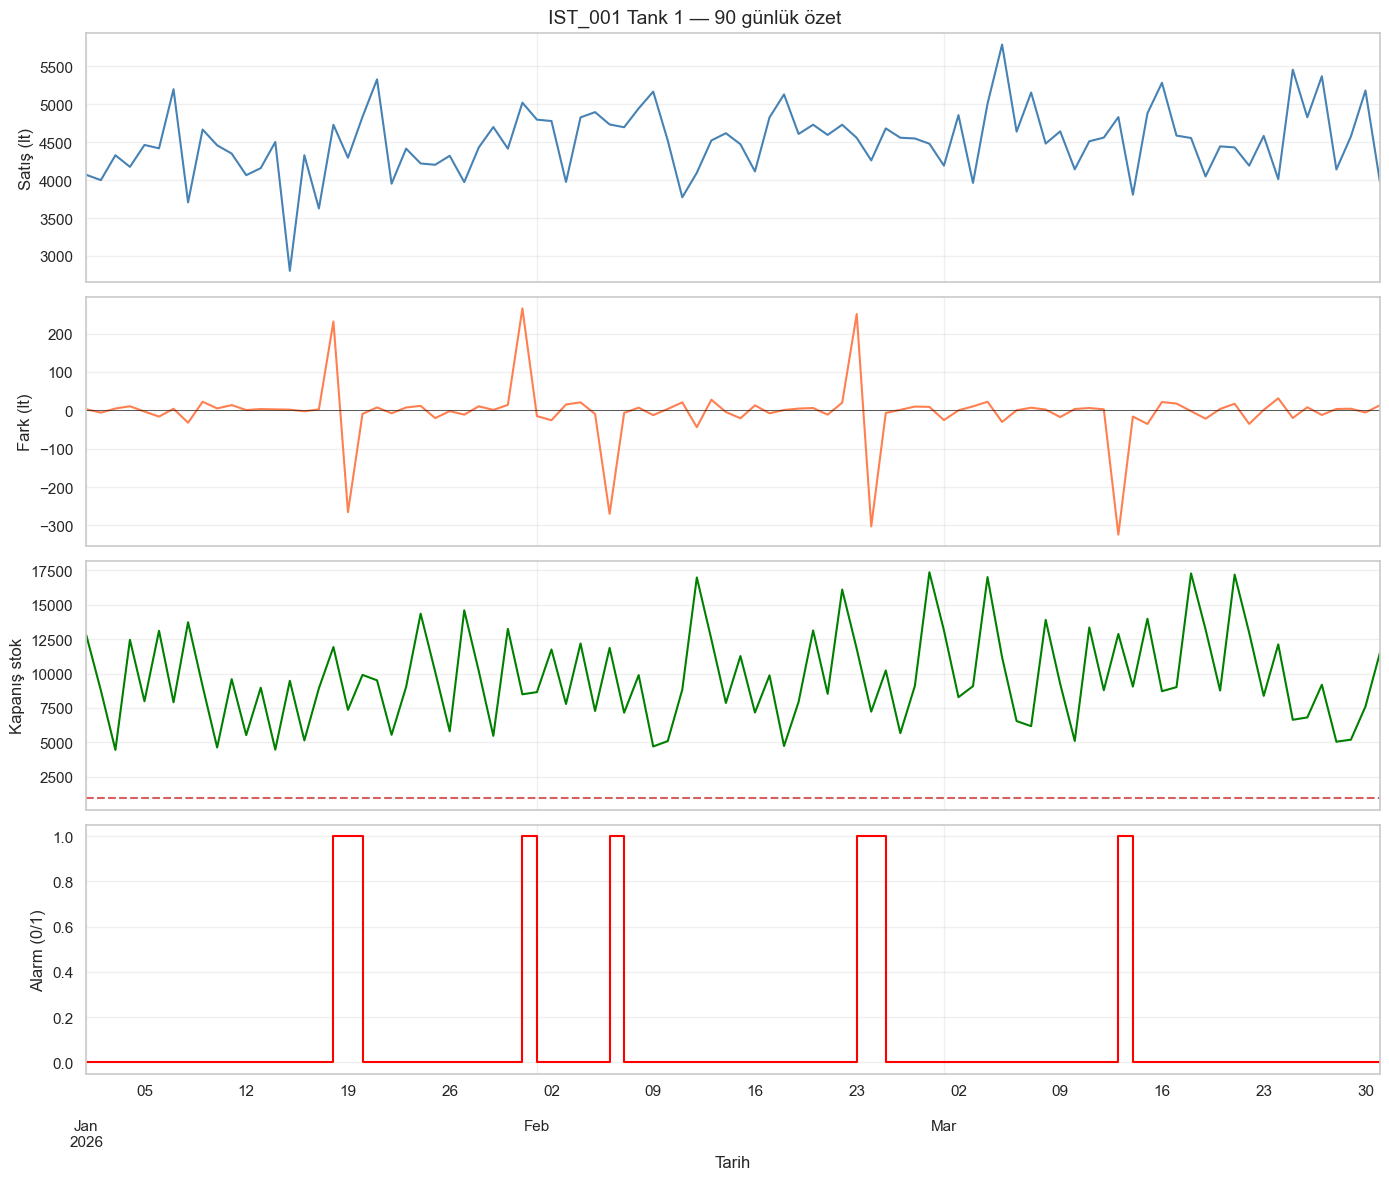

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/04_single_tank/04_single_tank_01.png')

In [23]:
# Günlük zaman serisi — 4 panel
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
daily.plot(x='tarih', y='satis', ax=axes[0], legend=False, color='steelblue')
axes[0].set_ylabel('Satış (lt)')
daily.plot(x='tarih', y='fark', ax=axes[1], legend=False, color='coral')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_ylabel('Fark (lt)')
daily.plot(x='tarih', y='kapanis', ax=axes[2], legend=False, color='green')
axes[2].axhline(tank_info.kapasite.iloc[0]*0.04, color='r', ls='--', label='dead stock ~4%')
axes[2].set_ylabel('Kapanış stok')
daily.plot(x='tarih', y='alarm', ax=axes[3], legend=False, drawstyle='steps-post', color='red')
axes[3].set_ylabel('Alarm (0/1)')
axes[3].set_xlabel('Tarih')
fig.suptitle(f'{IST} Tank {TANK} — 90 günlük özet', fontsize=14)
plt.tight_layout()
set_section('04_single_tank')
save_fig(name='04_single_tank_01')


Seçilen gün: 2026-03-13 | günlük fark: -324.20 lt


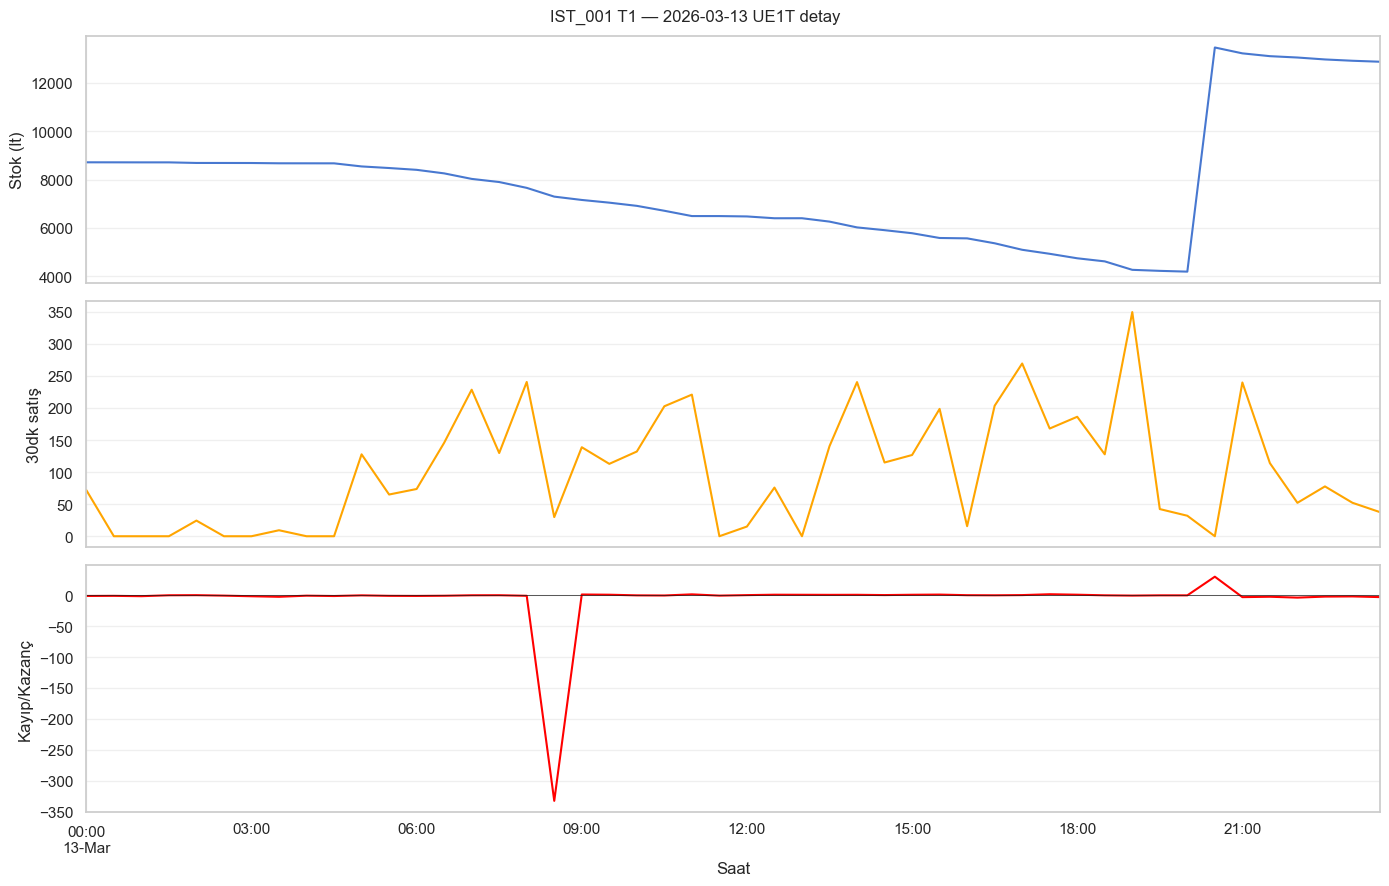

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/04_single_tank/04_single_tank_02.png')

In [24]:
# Tek gün 30 dk detay — en yüksek |fark| günü
gun = daily.loc[daily['fark'].abs().idxmax(), 'tarih']
u_gun = ue1t[ue1t.saat_1.dt.normalize() == gun]
print(f'Seçilen gün: {gun.date()} | günlük fark: {daily[daily.tarih==gun].fark.values[0]:.2f} lt')

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
u_gun.plot(x='saat_1', y='donem_sonu_stok', ax=axes[0], legend=False)
axes[0].set_ylabel('Stok (lt)')
u_gun.plot(x='saat_1', y='pompa_satis', ax=axes[1], legend=False, color='orange')
axes[1].set_ylabel('30dk satış')
u_gun.plot(x='saat_1', y='kayip_kazanc', ax=axes[2], legend=False, color='red')
axes[2].axhline(0, color='k', lw=0.5)
axes[2].set_ylabel('Kayıp/Kazanç')
axes[2].set_xlabel('Saat')
fig.suptitle(f'{IST} T{TANK} — {gun.date()} UE1T detay')
plt.tight_layout()
set_section('04_single_tank')
save_fig(name='04_single_tank_02')


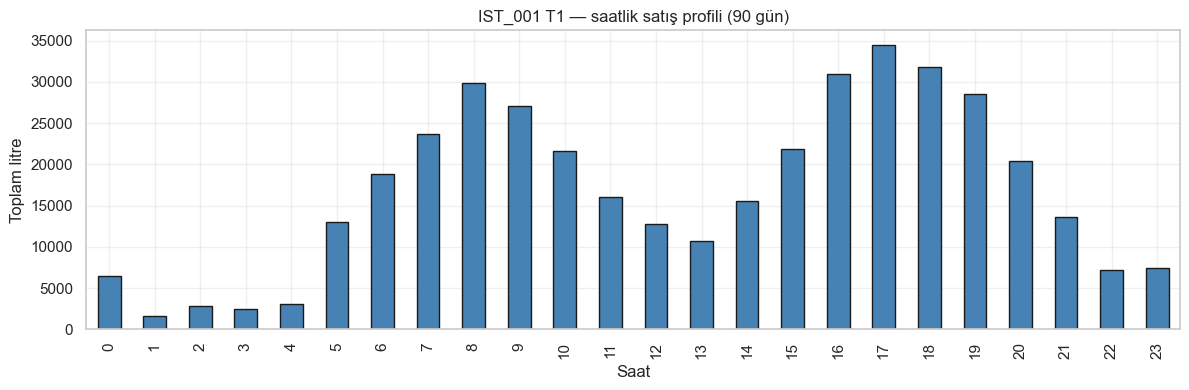

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/04_single_tank/04_single_tank_03.png')

In [25]:
# Saatlik satış profili (tüm dönem)
tx2 = tx.copy()
tx2['saat'] = tx2['satis_zamani'].dt.hour + tx2['satis_zamani'].dt.minute/60
profil = tx2.groupby(tx2['satis_zamani'].dt.floor('h'))['litre'].sum()
profil.index = profil.index.hour

hourly = tx2.groupby(tx2['satis_zamani'].dt.hour)['litre'].sum()
fig, ax = plt.subplots(figsize=(12, 4))
hourly.plot(kind='bar', ax=ax, color='steelblue', edgecolor='k')
ax.set_xlabel('Saat')
ax.set_ylabel('Toplam litre')
ax.set_title(f'{IST} T{TANK} — saatlik satış profili (90 gün)')
plt.tight_layout()
set_section('04_single_tank')
save_fig(name='04_single_tank_03')


Join sonrası satır: 4320 | null sicaklik: 0


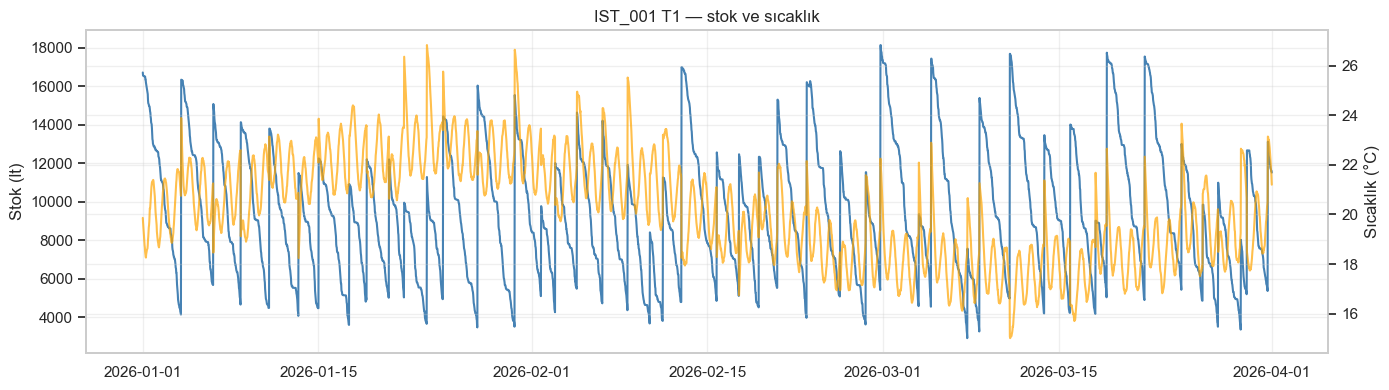

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/04_single_tank/04_single_tank_04.png')

In [26]:
# UE1T + Envanter join
merged = merge_ue1t_inventory(ue1t, inv)
print('Join sonrası satır:', len(merged), '| null sicaklik:', merged['sicaklik_inv'].isna().sum() if 'sicaklik_inv' in merged.columns else merged.filter(like='sicaklik').isna().sum().sum())

fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(merged['saat_1'], merged['donem_sonu_stok'], label='Stok (UE1T)', color='steelblue')
ax1.set_ylabel('Stok (lt)')
ax2 = ax1.twinx()
ax2.plot(merged['saat_1'], merged['sicaklik_ue1t'], label='Sıcaklık', color='orange', alpha=0.7)
ax2.set_ylabel('Sıcaklık (°C)')
ax1.set_title(f'{IST} T{TANK} — stok ve sıcaklık')
fig.tight_layout()
set_section('04_single_tank')
save_fig(name='04_single_tank_04')


,dolum_baslangic,dolum_net,dolum_oncesi_hacim,dolum_sonrasi_hacim,sicaklik
4,2026-01-04 01:33:00,"12,166.43","4,138.69","16,305.12",25.24
8,2026-01-06 15:04:00,"9,559.16","5,673.31","15,232.47",20.91
14,2026-01-08 19:31:00,"9,555.01","4,656.49","14,211.50",21.94
17,2026-01-11 02:07:00,"9,303.28","4,480.97","13,784.25",26.66
22,2026-01-13 10:08:00,"7,596.69","4,069.49","11,666.18",20.47
27,2026-01-15 00:39:00,"7,807.40","4,468.25","12,275.65",NaN
32,2026-01-17 11:00:00,"7,410.59","3,599.40","11,009.99",24.83
35,2026-01-18 20:40:00,"7,494.16","4,900.34","12,394.50",25.25
39,2026-01-20 15:01:00,"7,380.64","5,012.62","12,393.26",24.28
42,2026-01-21 20:07:00,"4,928.20","5,028.16","9,956.36",30.02


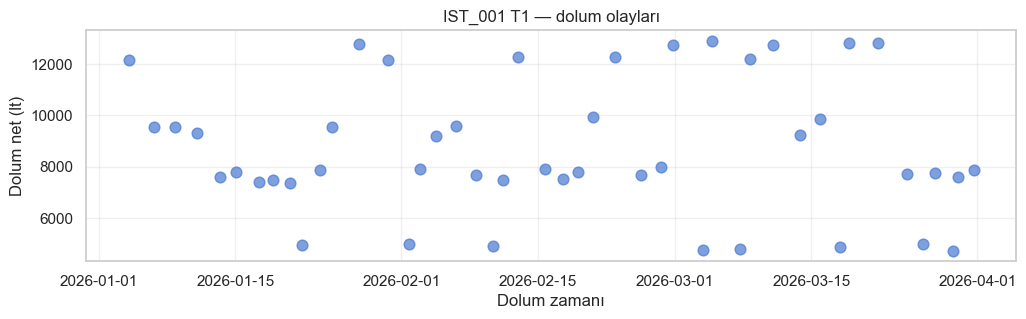

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/04_single_tank/04_single_tank_05.png')

In [27]:
# Dolum olayları
if len(deliv):
    display(deliv[['dolum_baslangic','dolum_net','dolum_oncesi_hacim','dolum_sonrasi_hacim','sicaklik']].head(10))
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.scatter(deliv['dolum_baslangic'], deliv['dolum_net'], s=60, alpha=0.7)
    ax.set_xlabel('Dolum zamanı')
    ax.set_ylabel('Dolum net (lt)')
    ax.set_title(f'{IST} T{TANK} — dolum olayları')
    set_section('04_single_tank')
save_fig(name='04_single_tank_05')


## Sonuç

Tek tank üzerinde günlük özet → 30 dk detay → tekil satış → envanter akışını gördük.

Sonraki: tüm tanklar için günlük alarm analizi (`05_gunluk_alarm_ve_fark.ipynb`).

---
## BÖLÜM 5 — Günlük alarm ve fark

Kaynak: `notebooks/05_gunluk_alarm_ve_fark.ipynb`


In [28]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all
from utils.plots import setup_style

setup_style()
daily = load_all()['daily']
daily['fark_abs'] = daily['fark'].abs()
daily['sel_asildi'] = daily['fark_abs'] > daily['sel']


In [29]:
print('Alarm oranı:', daily['alarm'].mean())
print('SEL aşım oranı (manuel kontrol):', daily['sel_asildi'].mean())
print('Alarm ile SEL tutarlı mı:', (daily['alarm'] == daily['sel_asildi'].astype(int)).mean())


Alarm oranı: 0.059375
SEL aşım oranı (manuel kontrol): 0.059375
Alarm ile SEL tutarlı mı: 1.0


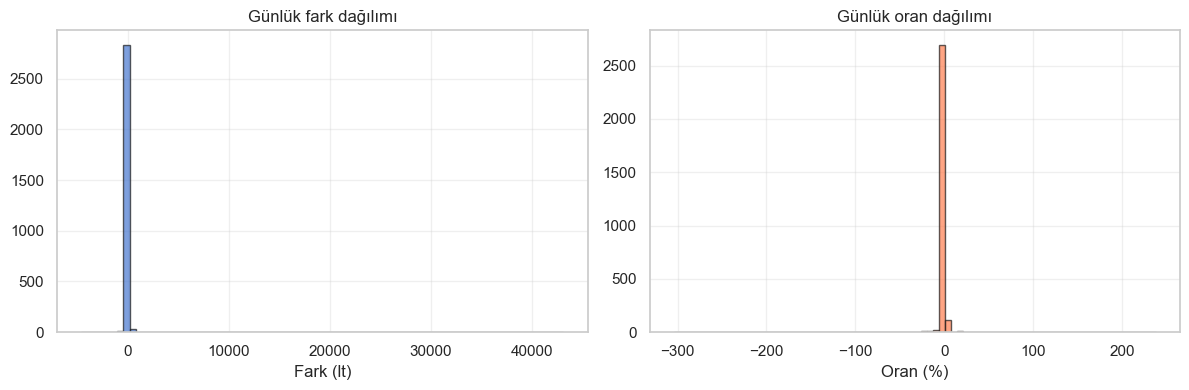

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/05_daily_alarm/05_daily_alarm_01.png')

In [30]:
# Fark dağılımı
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
daily['fark'].hist(bins=80, ax=axes[0], edgecolor='k', alpha=0.7)
axes[0].set_xlabel('Fark (lt)'); axes[0].set_title('Günlük fark dağılımı')
daily['oran'].hist(bins=80, ax=axes[1], edgecolor='k', alpha=0.7, color='coral')
axes[1].set_xlabel('Oran (%)'); axes[1].set_title('Günlük oran dağılımı')
plt.tight_layout()
set_section('05_daily_alarm')
save_fig(name='05_daily_alarm_01')


En çok alarm üreten tanklar:


,istasyon_kodu,tank_no,alarm
11,IST_003,2,16
20,IST_005,3,15
18,IST_005,1,15
26,IST_007,2,14
28,IST_007,4,10
16,IST_004,4,9
14,IST_004,2,9
10,IST_003,1,8
5,IST_002,1,8
17,IST_004,5,7


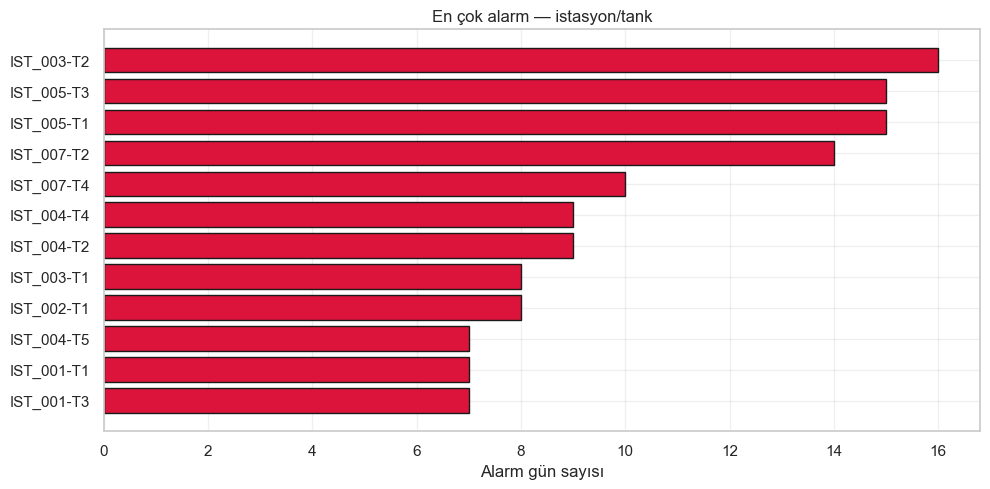

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/05_daily_alarm/05_daily_alarm_02.png')

In [31]:
# Alarm sayısı — istasyon × tank
alarm_cnt = daily.groupby(['istasyon_kodu','tank_no'])['alarm'].sum().reset_index()
alarm_cnt = alarm_cnt.sort_values('alarm', ascending=False)
print('En çok alarm üreten tanklar:')
display(alarm_cnt.head(15))

plt.figure(figsize=(10, 5))
top = alarm_cnt.head(12)
labels = top['istasyon_kodu'] + '-T' + top['tank_no'].astype(str)
plt.barh(labels, top['alarm'], color='crimson', edgecolor='k')
plt.xlabel('Alarm gün sayısı')
plt.title('En çok alarm — istasyon/tank')
plt.gca().invert_yaxis()
plt.tight_layout()
set_section('05_daily_alarm')
save_fig(name='05_daily_alarm_02')


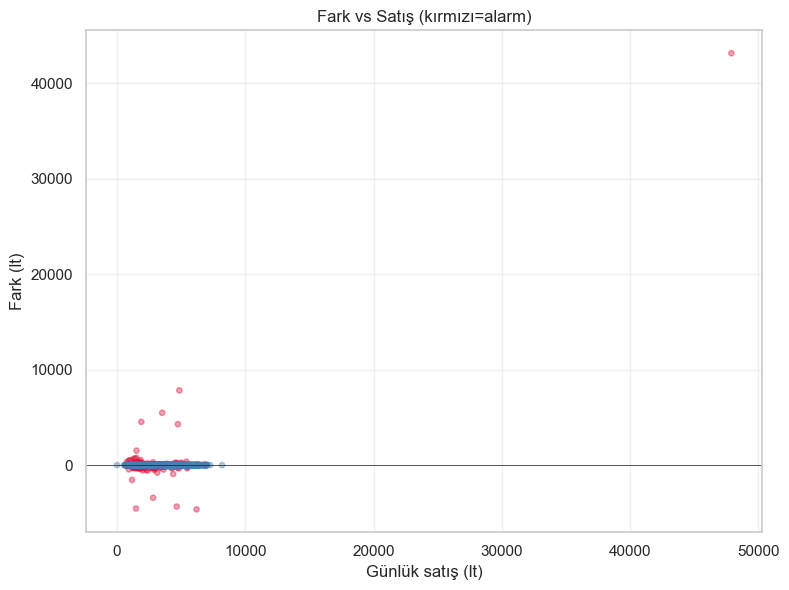

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/05_daily_alarm/05_daily_alarm_03.png')

In [32]:
# Fark vs satış scatter
plt.figure(figsize=(8, 6))
colors = daily['alarm'].map({0: 'steelblue', 1: 'crimson'})
plt.scatter(daily['satis'], daily['fark'], c=colors, alpha=0.4, s=15)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('Günlük satış (lt)')
plt.ylabel('Fark (lt)')
plt.title('Fark vs Satış (kırmızı=alarm)')
plt.tight_layout()
set_section('05_daily_alarm')
save_fig(name='05_daily_alarm_03')


In [33]:
# Mutabakat denklemi kontrolü: fark = satis - azalma
daily['fark_hesap'] = daily['satis'] - daily['azalma_miktari']
daily['fark_residual'] = daily['fark'] - daily['fark_hesap']
print('Fark denklemi max residual:', daily['fark_residual'].abs().max())


Fark denklemi max residual: 7.275957614183426e-12


Sonraki: envanter, su, sıcaklık (`06_envanter_su_sicaklik.ipynb`).

---
## BÖLÜM 6 — Envanter, su, sıcaklık

Kaynak: `notebooks/06_envanter_su_sicaklik.ipynb`


In [34]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all
from utils.plots import setup_style

setup_style()
inv = load_all()['inventory_30min']
inv['brut_net_fark'] = inv['urun_miktari_brut'] - inv['urun_miktari_net']
inv['gecikme_dk'] = (inv['merkeze_gelis_tarihi'] - inv['envanter_tarihi']).dt.total_seconds()/60


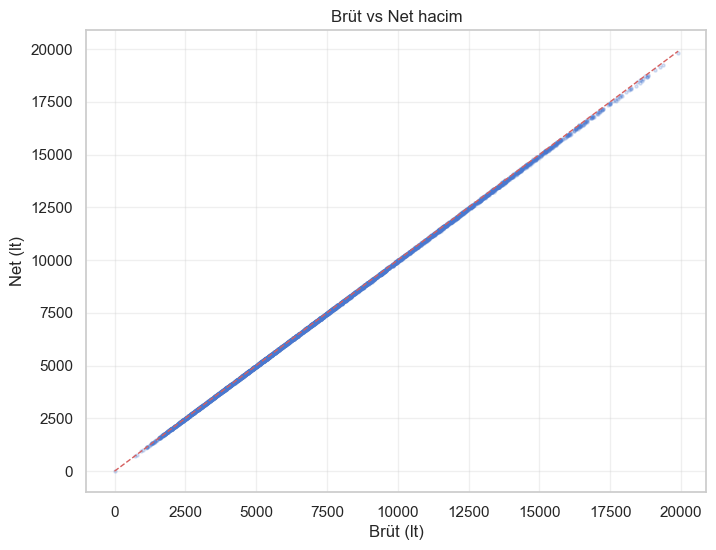

Brüt-Net fark istatistikleri:
count   137,954.00
mean         37.31
std          25.42
min         -23.72
25%          18.66
50%          31.35
75%          49.47
max         202.90
Name: brut_net_fark, dtype: float64


In [35]:
# Brüt vs Net
fig, ax = plt.subplots(figsize=(8, 6))
sample = inv.dropna(subset=['urun_miktari_net']).sample(min(5000, len(inv)), random_state=42)
ax.scatter(sample['urun_miktari_brut'], sample['urun_miktari_net'], alpha=0.2, s=5)
ax.plot([0, sample['urun_miktari_brut'].max()], [0, sample['urun_miktari_brut'].max()], 'r--', lw=1)
ax.set_xlabel('Brüt (lt)'); ax.set_ylabel('Net (lt)')
ax.set_title('Brüt vs Net hacim')
set_section('06_inventory')
save_fig(name='06_inventory_01')

print('Brüt-Net fark istatistikleri:')
print(inv['brut_net_fark'].describe())


In [36]:
# Su seviyesi — sıfır olmayan tank-günler
su_pos = inv[inv['su_seviyesi_cm'].fillna(0) > 0.5]
print('Su > 0.5 cm satır:', len(su_pos))
if len(su_pos):
    su_tank = su_pos.groupby(['istasyon_kodu','tank_no']).size().sort_values(ascending=False)
    print('En çok su kaydı olan tanklar:')
    print(su_tank.head(10))


Su > 0.5 cm satır: 137785
En çok su kaydı olan tanklar:
istasyon_kodu  tank_no
IST_001        1          4320
IST_003        2          4320
IST_008        2          4320
               1          4320
IST_006        4          4320
               2          4320
               1          4320
IST_004        3          4320
               2          4320
               1          4320
dtype: int64


In [37]:
# Su artış hızı — su faktörü adayı
inv2 = inv.sort_values(['istasyon_kodu','tank_no','envanter_tarihi']).copy()
inv2['su_diff'] = inv2.groupby(['istasyon_kodu','tank_no'])['su_seviyesi_cm'].diff()
spike = inv2[inv2['su_diff'] > 0.05]
print('Su sıçrama (>0.05 cm/30dk) satır:', len(spike))
if len(spike):
    display(spike.nlargest(10, 'su_diff')[['envanter_tarihi','istasyon_kodu','tank_no','su_seviyesi_cm','su_diff']])


Su sıçrama (>0.05 cm/30dk) satır: 85


,envanter_tarihi,istasyon_kodu,tank_no,su_seviyesi_cm,su_diff
36184,2026-03-02 18:30:00,IST_002,5,14.48,14.48
36182,2026-03-02 18:30:00,IST_002,3,5.87,5.87
16116,2026-03-09 04:00:00,IST_001,2,5.86,5.86
36180,2026-03-02 18:30:00,IST_002,1,5.62,5.62
36181,2026-03-02 18:30:00,IST_002,2,5.21,5.21
36183,2026-03-02 18:30:00,IST_002,4,4.96,4.96
31729,2026-02-12 05:00:00,IST_002,5,11.27,0.06
31799,2026-02-12 12:00:00,IST_002,5,11.99,0.06
31679,2026-02-12 00:00:00,IST_002,5,10.82,0.06
31154,2026-02-09 19:30:00,IST_002,5,5.88,0.06


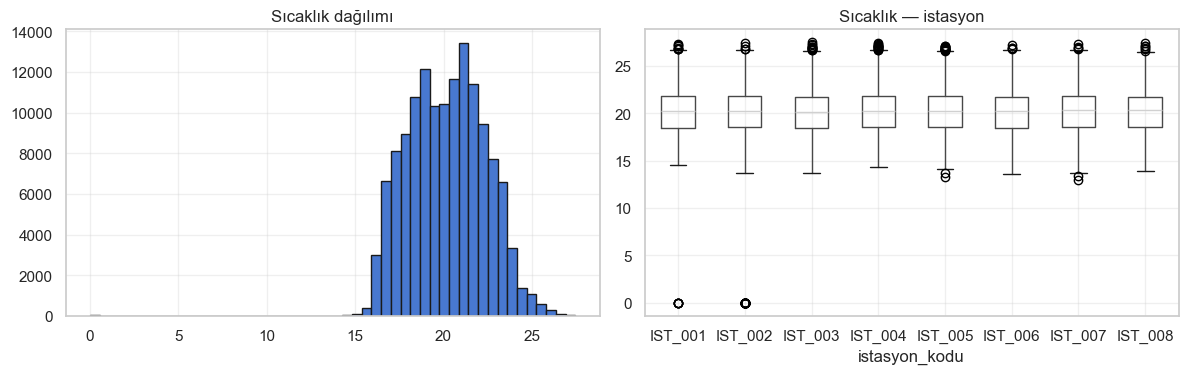

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/06_inventory/06_inventory_02.png')

In [38]:
# Sıcaklık dağılımı
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
inv['sicaklik'].dropna().hist(bins=50, ax=axes[0], edgecolor='k')
axes[0].set_title('Sıcaklık dağılımı')
inv.boxplot(column='sicaklik', by='istasyon_kodu', ax=axes[1])
axes[1].set_title('Sıcaklık — istasyon')
plt.suptitle('')
plt.tight_layout()
set_section('06_inventory')
save_fig(name='06_inventory_02')


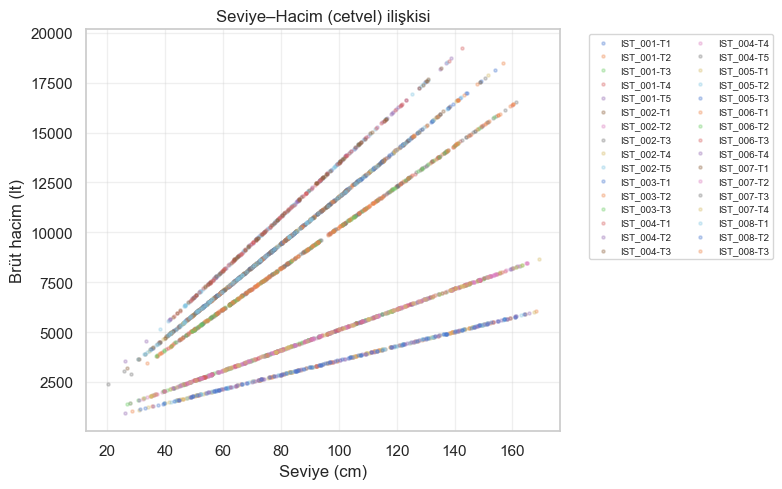

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/06_inventory/06_inventory_03.png')

In [39]:
# Seviye (cm) vs hacim (lt) — strapping ilişkisi
sample = inv.dropna(subset=['urun_seviyesi_cm','urun_miktari_brut']).sample(min(3000,len(inv)), random_state=1)
plt.figure(figsize=(8, 5))
for (ist, tn), g in sample.groupby(['istasyon_kodu','tank_no']):
    if len(g) > 20:
        plt.scatter(g['urun_seviyesi_cm'], g['urun_miktari_brut'], alpha=0.3, s=5, label=f'{ist}-T{tn}')
plt.xlabel('Seviye (cm)'); plt.ylabel('Brüt hacim (lt)')
plt.title('Seviye–Hacim (cetvel) ilişkisi')
plt.legend(bbox_to_anchor=(1.05,1), fontsize=7, ncol=2)
plt.tight_layout()
set_section('06_inventory')
save_fig(name='06_inventory_03')


Sonraki: satış ve dolum (`07_satis_ve_dolum.ipynb`).

---
## BÖLÜM 7 — Satış ve dolum

Kaynak: `notebooks/07_satis_ve_dolum.ipynb`


In [40]:
# Satış istatistikleri
print('Toplam işlem:', len(tx))
print('Test satışı:', tx['test_satisi'].sum())
print('Satış tipi:', tx['satis_tipi'].value_counts().to_dict())
print('Litre istatistikleri:')
print(tx['litre'].describe())


Toplam işlem: 9609
Test satışı: 0
Satış tipi: {'Pompaci': 8186, 'Kendin Sec': 1423}
Litre istatistikleri:
count   9,594.00
mean       41.90
std        28.05
min         4.00
25%        21.23
50%        35.66
75%        56.22
max       160.00
Name: litre, dtype: float64


In [41]:
# Pompa decimal adayı: litre vs tutar/birim_fiyat
tx_ok = tx.dropna(subset=['litre','tutar','birim_fiyat'])
tx_ok = tx_ok[tx_ok['birim_fiyat'] > 0]
tx_ok['litre_hesap'] = tx_ok['tutar'] / tx_ok['birim_fiyat']
tx_ok['litre_oran'] = tx_ok['litre'] / tx_ok['litre_hesap']

# 10x sapma
decimal = tx_ok[(tx_ok['litre_oran'] > 5) | (tx_ok['litre_oran'] < 0.2)]
print('Decimal şüpheli işlem:', len(decimal))
if len(decimal):
    display(decimal.groupby(['istasyon_kodu','tank_no']).size().sort_values(ascending=False).head())


Decimal şüpheli işlem: 0


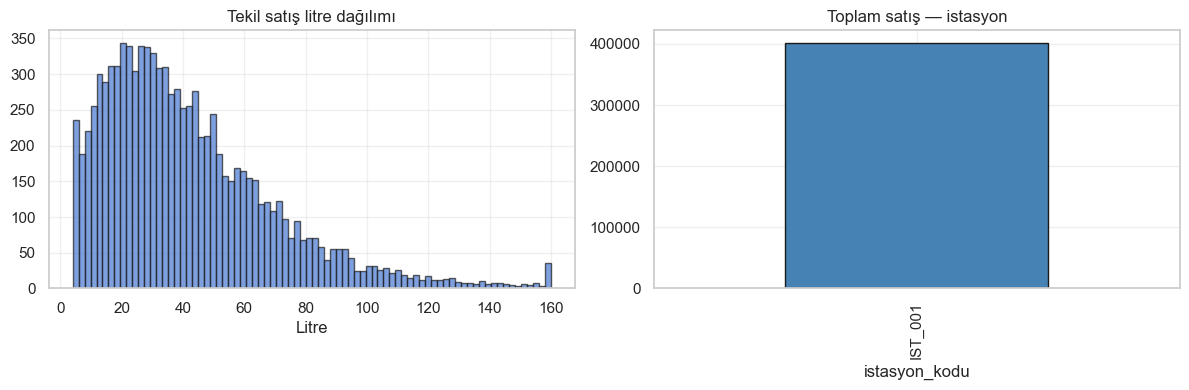

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/07_sales_delivery/07_sales_delivery_01.png')

In [42]:
# İşlem büyüklüğü dağılımı
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tx['litre'].hist(bins=80, ax=axes[0], edgecolor='k', alpha=0.7)
axes[0].set_xlabel('Litre'); axes[0].set_title('Tekil satış litre dağılımı')
tx.groupby('istasyon_kodu')['litre'].sum().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='k')
axes[1].set_title('Toplam satış — istasyon')
plt.tight_layout()
set_section('07_sales_delivery')
save_fig(name='07_sales_delivery_01')


In [43]:
# Dolum analizi
print('Toplam dolum kaydı:', len(deliv))
print('Dolum net istatistikleri:')
print(deliv['dolum_net'].describe())

deliv['tarih'] = deliv['dolum_baslangic'].dt.normalize()
dolum_gun = deliv.groupby(['istasyon_kodu','tank_no','tarih'])['dolum_net'].sum().reset_index()
print('\nEn büyük dolumlar:')
display(dolum_gun.nlargest(10, 'dolum_net'))


Toplam dolum kaydı: 46
Dolum net istatistikleri:
count       46.00
mean     8,719.95
std      2,609.80
min      4,721.71
25%      7,505.41
50%      7,894.46
75%      9,904.08
max     12,910.50
Name: dolum_net, dtype: float64

En büyük dolumlar:


,istasyon_kodu,tank_no,tarih,dolum_net
31,IST_001,1,2026-03-04,"12,910.50"
39,IST_001,1,2026-03-21,"12,840.73"
38,IST_001,1,2026-03-18,"12,821.02"
12,IST_001,1,2026-01-27,"12,774.67"
34,IST_001,1,2026-03-11,"12,751.46"
29,IST_001,1,2026-02-28,"12,731.16"
21,IST_001,1,2026-02-12,"12,289.56"
26,IST_001,1,2026-02-22,"12,288.04"
33,IST_001,1,2026-03-08,"12,208.24"
13,IST_001,1,2026-01-30,"12,178.34"


In [44]:
# Dolum sonrası envanter artışı vs kayıtlı dolum — ue1t join
ue1t = dfs['ue1t_30min']
dolum_donem = ue1t[ue1t['tanka_dolum'] > 100][['saat_1','istasyon_kodu','tank_no','tanka_dolum','kayip_kazanc']]
print('UE1T dolumlu dönem (>100 lt):', len(dolum_donem))
display(dolum_donem.nlargest(10, 'tanka_dolum'))


UE1T dolumlu dönem (>100 lt): 1109


,saat_1,istasyon_kodu,tank_no,tanka_dolum,kayip_kazanc
78017,2026-01-02 18:30:00,IST_005,3,"12,994.52",-30.48
111778,2026-01-20 17:00:00,IST_007,1,"12,981.96",-40.96
84477,2026-02-16 15:30:00,IST_005,1,"12,979.52",49.90
6589,2026-01-28 10:30:00,IST_001,5,"12,972.47",-44.40
117322,2026-02-18 19:00:00,IST_007,1,"12,966.21",-39.20
61302,2026-01-22 10:00:00,IST_004,3,"12,964.69",22.66
10814,2026-02-15 01:00:00,IST_001,5,"12,963.08",56.22
60260,2026-01-18 02:00:00,IST_004,1,"12,950.70",45.39
72437,2026-03-09 19:30:00,IST_004,3,"12,942.30",34.24
16989,2026-03-12 18:30:00,IST_001,5,"12,929.94",-42.85


Sonraki: manifold ve bölmeli tanklar (`08_manifold_bolmeli.ipynb`).

---
## BÖLÜM 8 — Manifold ve bölmeli

Kaynak: `notebooks/08_manifold_bolmeli.ipynb`


In [45]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all
from utils.plots import setup_style

setup_style()
dfs = load_all()
tanks = dfs['tanks']
ue1t = dfs['ue1t_30min']

manifold = tanks[tanks['is_manifold']==1]
bolmeli = tanks[tanks['bolmeli']==1]
print('Manifoldlu tanklar:', len(manifold))
display(manifold[['istasyon_kodu','tank_no','manifold_grup_no','akaryakit_turu']])
print('\nBölmeli tanklar:', len(bolmeli))
display(bolmeli[['istasyon_kodu','tank_no','bolme_grup_no']])


Manifoldlu tanklar: 8


,istasyon_kodu,tank_no,manifold_grup_no,akaryakit_turu
0,IST_001,1,1,Motorin(Excellium)
2,IST_001,3,1,Motorin(Excellium)
14,IST_004,2,1,KB 95 Oktan Excellium
16,IST_004,4,1,KB 95 Oktan Excellium
18,IST_005,1,1,Motorin(Excellium)
20,IST_005,3,1,Motorin(Excellium)
26,IST_007,2,1,KB 95 Oktan Excellium
28,IST_007,4,1,KB 95 Oktan Excellium



Bölmeli tanklar: 2


,istasyon_kodu,tank_no,bolme_grup_no
11,IST_003,2,1
12,IST_003,3,1


In [46]:
# Manifold çiftleri — aynı saatte ters yönlü kayıp/kazanç
pairs = []
for (ist, grp), g in manifold.groupby(['istasyon_kodu','manifold_grup_no']):
    tn = sorted(g['tank_no'].tolist())
    if len(tn) == 2:
        pairs.append((ist, tn[0], tn[1]))

print('Manifold çift sayısı:', len(pairs))
corrs = []
for ist, a, b in pairs[:6]:
    ua = ue1t[(ue1t.istasyon_kodu==ist)&(ue1t.tank_no==a)].set_index('saat_1')['kayip_kazanc']
    ub = ue1t[(ue1t.istasyon_kodu==ist)&(ue1t.tank_no==b)].set_index('saat_1')['kayip_kazanc']
    m = pd.concat([ua, ub], axis=1, keys=['a','b']).dropna()
    if len(m) > 50:
        corr = m['a'].corr(m['b'])
        corrs.append({'ist': ist, 'tank_a': a, 'tank_b': b, 'corr': corr})
        print(f'{ist} T{a}-T{b}: kayip_kazanc korelasyon = {corr:.3f}')

pd.DataFrame(corrs)


Manifold çift sayısı: 4
IST_001 T1-T3: kayip_kazanc korelasyon = -0.939
IST_004 T2-T4: kayip_kazanc korelasyon = -0.961
IST_005 T1-T3: kayip_kazanc korelasyon = -0.069
IST_007 T2-T4: kayip_kazanc korelasyon = -0.075


,ist,tank_a,tank_b,corr
0,IST_001,1,3,-0.94
1,IST_004,2,4,-0.96
2,IST_005,1,3,-0.07
3,IST_007,2,4,-0.08


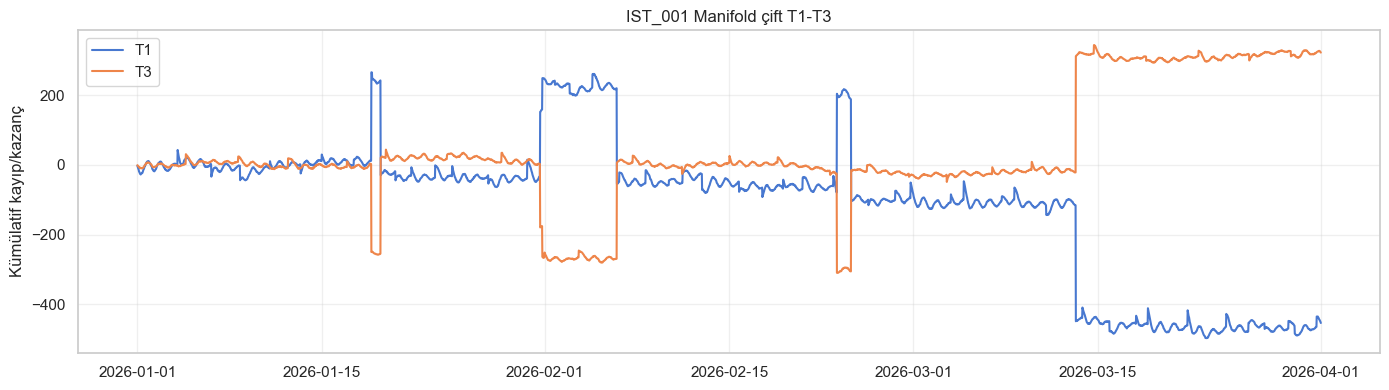

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/08_manifold/08_manifold_01.png')

In [47]:
# Örnek manifold çifti grafiği
if pairs:
    ist, a, b = pairs[0]
    ua = ue1t[(ue1t.istasyon_kodu==ist)&(ue1t.tank_no==a)].sort_values('saat_1')
    ub = ue1t[(ue1t.istasyon_kodu==ist)&(ue1t.tank_no==b)].sort_values('saat_1')
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(ua['saat_1'], ua['kayip_kazanc'].cumsum(), label=f'T{a}')
    ax.plot(ub['saat_1'], ub['kayip_kazanc'].cumsum(), label=f'T{b}')
    ax.set_ylabel('Kümülatif kayıp/kazanç')
    ax.legend()
    ax.set_title(f'{ist} Manifold çift T{a}-T{b}')
    plt.tight_layout()
    set_section('08_manifold')
save_fig(name='08_manifold_01')


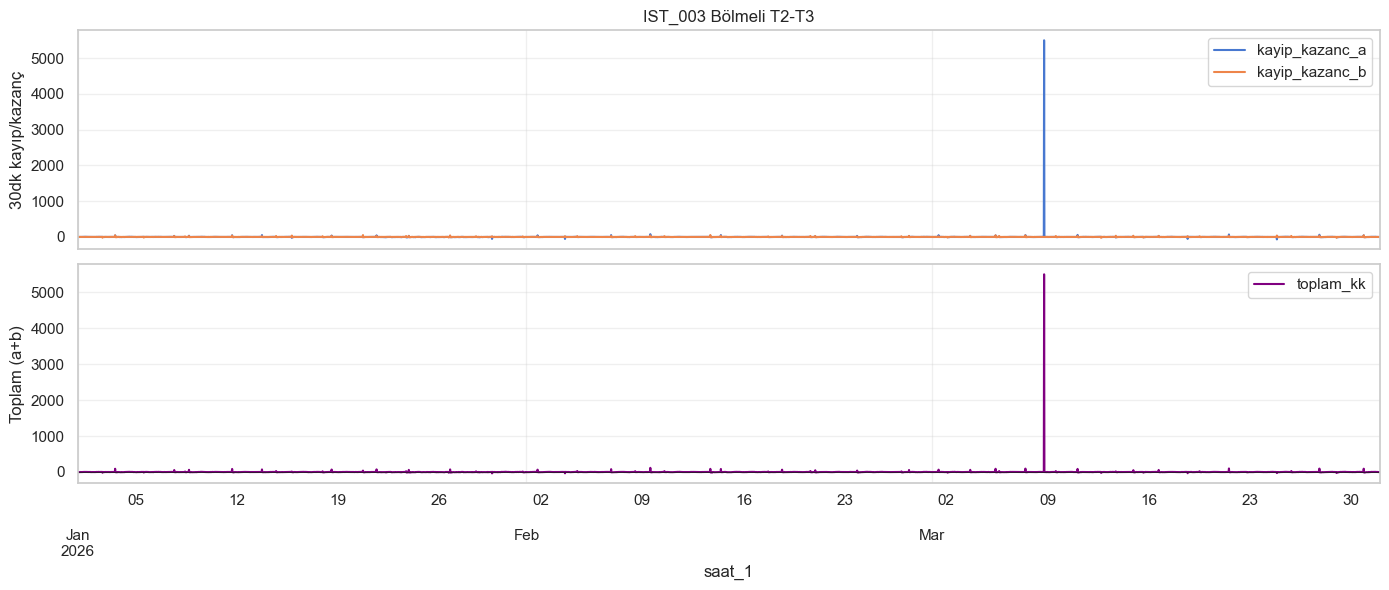

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/08_manifold/08_manifold_02.png')

In [48]:
# Bölmeli çift IST_003 T2-T3
ba, bb = 2, 3
ist = 'IST_003'
ua = ue1t[(ue1t.istasyon_kodu==ist)&(ue1t.tank_no==ba)].sort_values('saat_1')
ub = ue1t[(ue1t.istasyon_kodu==ist)&(ue1t.tank_no==bb)].sort_values('saat_1')
m = ua.merge(ub, on='saat_1', suffixes=('_a','_b'))
m['toplam_kk'] = m['kayip_kazanc_a'] + m['kayip_kazanc_b']

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
m.plot(x='saat_1', y=['kayip_kazanc_a','kayip_kazanc_b'], ax=axes[0])
axes[0].set_ylabel('30dk kayıp/kazanç')
axes[0].set_title(f'{ist} Bölmeli T{ba}-T{bb}')
m.plot(x='saat_1', y='toplam_kk', ax=axes[1], color='purple')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_ylabel('Toplam (a+b)')
plt.tight_layout()
set_section('08_manifold')
save_fig(name='08_manifold_02')


Sonraki: anomali keşfi (`09_anomali_kesfi.ipynb`).

---
## BÖLÜM 9 — Anomali keşfi

Kaynak: `notebooks/09_anomali_kesfi.ipynb`


In [49]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all, merge_ue1t_inventory
from utils.plots import setup_style

setup_style()
dfs = load_all()
ue1t = dfs['ue1t_30min'].copy()
inv = dfs['inventory_30min']


In [50]:
# Feature adayları — 30dk bazında
ue1t['satisiz'] = (ue1t['pompa_satis'] == 0).astype(int)
ue1t['kk_oran'] = np.where(ue1t['pompa_satis'] > 1,
                           ue1t['kayip_kazanc'] / ue1t['pompa_satis'], np.nan)
ue1t['saat'] = ue1t['saat_1'].dt.hour
ue1t['gece'] = ue1t['saat'].between(0, 5).astype(int)

print('Feature özet:')
print(ue1t[['kayip_kazanc','kk_oran','satisiz','gece']].describe())


Feature özet:
       kayip_kazanc   kk_oran    satisiz       gece
count    138,194.00 92,759.00 138,194.00 138,194.00
mean           0.29     -0.01       0.33       0.25
std           93.56      2.61       0.47       0.43
min      -14,138.41   -589.59       0.00       0.00
25%           -0.93     -0.01       0.00       0.00
50%           -0.09      0.00       0.00       0.00
75%            0.70      0.01       1.00       1.00
max       13,540.13    116.75       1.00       1.00


In [51]:
# Sinyal 1: Satışsız kayıp (statik sızıntı adayı)
satisiz_kayip = ue1t[(ue1t['pompa_satis']==0) & (ue1t['kayip_kazanc'] < -5)]
print('Satışsız kayıp >5 lt dönem:', len(satisiz_kayip))
top = satisiz_kayip.nsmallest(10, 'kayip_kazanc')
display(top[['saat_1','istasyon_kodu','tank_no','kayip_kazanc','donem_basi_stok','donem_sonu_stok']])


Satışsız kayıp >5 lt dönem: 450


,saat_1,istasyon_kodu,tank_no,kayip_kazanc,donem_basi_stok,donem_sonu_stok
110877,2026-01-16 00:00:00,IST_007,4,"-4,533.49","7,746.15","7,745.49"
16091,2026-03-09 01:00:00,IST_001,2,"-2,295.75","2,295.75",0.00
25923,2026-01-19 00:00:00,IST_002,4,"-1,515.91","1,822.45","4,973.58"
136689,2026-03-21 13:00:00,IST_008,2,-451.40,"1,626.20","1,174.80"
81521,2026-01-27 02:30:00,IST_005,3,-349.92,"11,405.23","11,055.31"
12767,2026-02-23 04:30:00,IST_001,3,-284.93,"5,084.55","4,799.62"
65796,2026-02-10 03:30:00,IST_004,2,-236.09,"4,461.62","4,225.53"
71748,2026-03-06 22:30:00,IST_004,4,-227.90,"2,861.90","2,634.00"
74103,2026-03-16 18:00:00,IST_004,4,-183.49,"2,642.17","2,458.68"
7352,2026-01-31 15:00:00,IST_001,3,-182.00,"3,270.64","3,088.64"


In [52]:
# Sinyal 2: Gece satışsız düşüş (pompacı manipülasyonu adayı)
gece = ue1t[(ue1t['gece']==1) & (ue1t['pompa_satis']==0) & (ue1t['kayip_kazanc'] < -20)]
print('Gece satışsız düşüş >20 lt:', len(gece))
if len(gece):
    display(gece.nsmallest(5,'kayip_kazanc')[['saat_1','istasyon_kodu','tank_no','kayip_kazanc']])


Gece satışsız düşüş >20 lt: 20


,saat_1,istasyon_kodu,tank_no,kayip_kazanc
110877,2026-01-16 00:00:00,IST_007,4,"-4,533.49"
16091,2026-03-09 01:00:00,IST_001,2,"-2,295.75"
25923,2026-01-19 00:00:00,IST_002,4,"-1,515.91"
81521,2026-01-27 02:30:00,IST_005,3,-349.92
12767,2026-02-23 04:30:00,IST_001,3,-284.93


In [53]:
# Sinyal 3: Yüksek kk_oran (dinamik sızıntı / decimal adayı)
high = ue1t[(ue1t['pompa_satis'] > 50) & (ue1t['kk_oran'].abs() > 0.05)]
print('|kk_oran| > 5% ve satış >50 lt:', len(high))
display(high.nlargest(10, 'kk_oran', keep='all')[['saat_1','istasyon_kodu','tank_no','pompa_satis','kayip_kazanc','kk_oran']].head(10))


|kk_oran| > 5% ve satış >50 lt: 1470


,saat_1,istasyon_kodu,tank_no,pompa_satis,kayip_kazanc,kk_oran
36182,2026-03-02 18:00:00,IST_002,3,115.98,"13,540.13",116.75
36181,2026-03-02 18:00:00,IST_002,2,66.76,"4,972.38",74.48
36184,2026-03-02 18:00:00,IST_002,5,180.93,"9,328.22",51.56
52816,2026-03-08 18:30:00,IST_003,2,128.57,"5,497.95",42.76
36180,2026-03-02 18:00:00,IST_002,1,312.72,"11,296.35",36.12
80118,2026-01-17 09:00:00,IST_005,1,239.68,"7,816.81",32.61
36183,2026-03-02 18:00:00,IST_002,4,106.61,"1,197.90",11.24
81519,2026-01-27 02:30:00,IST_005,1,64.67,348.55,5.39
86309,2026-03-01 09:30:00,IST_005,3,69.09,327.52,4.74
118817,2026-02-26 13:30:00,IST_007,4,50.94,219.61,4.31


In [54]:
# Sinyal 4: Seviye donması (şamandıra adayı) — stok değişmeden satış
ue1t_sorted = ue1t.sort_values(['istasyon_kodu','tank_no','saat_1'])
ue1t_sorted['stok_diff'] = ue1t_sorted.groupby(['istasyon_kodu','tank_no'])['donem_sonu_stok'].diff()
stuck = ue1t_sorted[(ue1t_sorted['pompa_satis'] > 30) & (ue1t_sorted['stok_diff'].abs() < 0.01)]
print('Satış var ama stok değişmedi:', len(stuck))
if len(stuck):
    display(stuck.head(8)[['saat_1','istasyon_kodu','tank_no','pompa_satis','donem_sonu_stok','kayip_kazanc']])


Satış var ama stok değişmedi: 45


,saat_1,istasyon_kodu,tank_no,pompa_satis,donem_sonu_stok,kayip_kazanc
36140,2026-03-02 14:00:00,IST_002,1,35.58,0.00,35.58
36145,2026-03-02 14:30:00,IST_002,1,174.02,0.00,174.02
36150,2026-03-02 15:00:00,IST_002,1,143.78,0.00,143.78
36155,2026-03-02 15:30:00,IST_002,1,83.05,0.00,83.05
36160,2026-03-02 16:00:00,IST_002,1,39.95,0.00,39.95
36165,2026-03-02 16:30:00,IST_002,1,116.48,0.00,116.48
36170,2026-03-02 17:00:00,IST_002,1,368.52,0.00,368.52
36175,2026-03-02 17:30:00,IST_002,1,63.37,0.00,63.37


In [55]:
# Sinyal 5: Su sıçraması
inv2 = inv.sort_values(['istasyon_kodu','tank_no','envanter_tarihi']).copy()
inv2['su_diff'] = inv2.groupby(['istasyon_kodu','tank_no'])['su_seviyesi_cm'].diff()
su = inv2[inv2['su_diff'] > 0.05]
print('Su sıçrama:', len(su))


Su sıçrama: 85


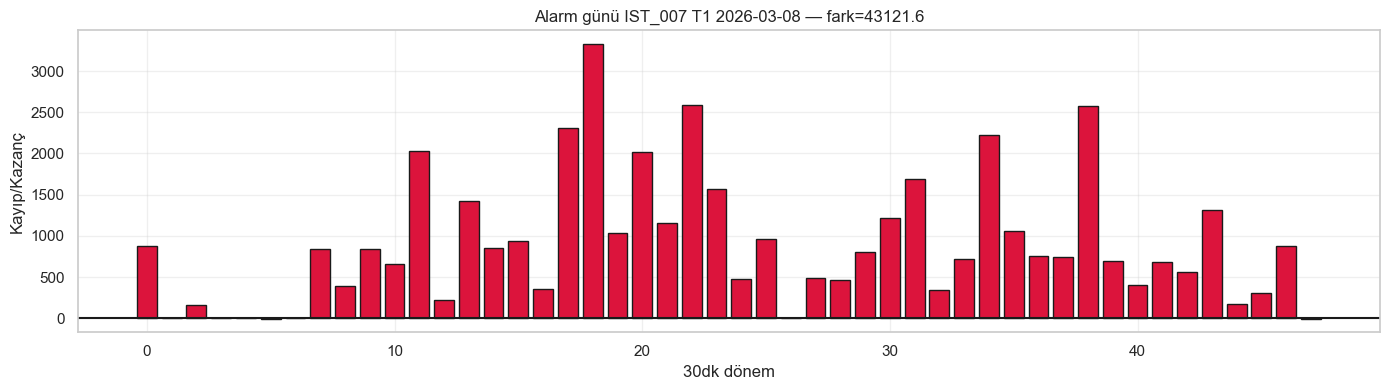

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/09_anomaly/09_anomaly_01.png')

In [56]:
# Günlük alarm günlerinde 30dk profili
daily = dfs['daily']
alarm_gun = daily[daily['alarm']==1].nlargest(1, 'fark')
if len(alarm_gun):
    row = alarm_gun.iloc[0]
    u = ue1t[(ue1t.istasyon_kodu==row.istasyon_kodu)&(ue1t.tank_no==row.tank_no)
             &(ue1t.saat_1.dt.normalize()==row.tarih)]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(len(u)), u['kayip_kazanc'], color='crimson', edgecolor='k')
    ax.axhline(0, color='k')
    ax.set_xlabel('30dk dönem')
    ax.set_ylabel('Kayıp/Kazanç')
    ax.set_title(f"Alarm günü {row.istasyon_kodu} T{row.tank_no} {row.tarih.date()} — fark={row.fark:.1f}")
    plt.tight_layout()
    set_section('09_anomaly')
save_fig(name='09_anomaly_01')


## Sonuç ve sonraki adımlar

**Keşfedilen sinyaller → feature engineering:**
- `satisiz_kayip`, `kk_oran`, `gece_satisiz_dusus`
- `tx_ue1t_fark`, `su_diff`, `gecikme_dk`
- Manifold çift korelasyonu

**ML aşaması:**
1. Feature'ları birleştir
2. Zaman bazlı train/test split (son 20 gün test)
3. `ground_truth/labels_30min.csv` ile karşılaştır
4. Baseline: SEL alarm vs CatBoost/IsolationForest

---
## BÖLÜM 10 — Derin EDA (Gün 7)

Kaynak: `notebooks/10_gun07_derin_eda.ipynb`


In [57]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda':
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all, filter_tank, merge_ue1t_inventory, summary_table
from utils.validation import run_all_checks, check_tx_to_ue1t
from utils.plots import setup_style, save_fig, set_section

setup_style()
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

dfs = load_all()
ue   = dfs['ue1t_30min'].copy()
tanks = dfs['tanks'].copy()
inv  = dfs['inventory_30min'].copy()
daily = dfs['daily'].copy()
tx   = dfs['transactions'].copy()
deliv = dfs['deliveries'].copy()
mapping = dfs['mapping'].copy()
stations = dfs['stations'].copy()

ue = ue.sort_values(['istasyon_kodu', 'tank_no', 'saat_1']).reset_index(drop=True)
print('=== Yüklenen tablolar ===')
for k, v in dfs.items():
    print(f'  {k:18} {v.shape[0]:>8,} satır × {v.shape[1]} kolon')


=== Yüklenen tablolar ===
  stations                  8 satır × 3 kolon
  tanks                    32 satır × 11 kolon
  mapping                  81 satır × 7 kolon
  transactions        231,874 satır × 11 kolon
  deliveries            1,109 satır × 12 kolon
  inventory_30min     138,194 satır × 11 kolon
  ue1t_30min          138,194 satır × 16 kolon
  daily                 2,880 satır × 13 kolon


## 0. Veri envanteri — tüm tablolar

8 operasyonel tablonun satır/kolon/null özeti ve tarih aralıkları.

In [58]:
# Tablo özeti
ozet = summary_table(dfs)
display(ozet)

# Tarih aralıkları
print('\n=== Tarih aralıkları ===')
print(f'daily     : {daily.tarih.min().date()} → {daily.tarih.max().date()}  ({daily.tarih.nunique()} gün)')
print(f'ue1t      : {ue.saat_1.min()} → {ue.saat_1.max()}')
print(f'tx        : {tx.satis_zamani.min()} → {tx.satis_zamani.max()}')
print(f'deliveries: {deliv.dolum_baslangic.min()} → {deliv.dolum_baslangic.max()}  ({len(deliv):,} kayıt)')

# İstasyon × tank matrisi
print('\n=== İstasyon / tank sayısı ===')
display(stations)
print(tanks.groupby('istasyon_kodu').size().to_string())

# Ürün dağılımı
print('\n=== Ürün türü (tank) ===')
print(tanks['akaryakit_turu'].value_counts().to_string())


,tablo,satir,kolon,null_kolon_sayisi,toplam_null,null_detay
0,stations,8,3,0,0,{}
1,tanks,32,11,0,0,{}
2,mapping,81,7,1,2,{'manifold_grup_no': 2}
3,transactions,231874,11,3,3938,"{'tank_no': 2548, 'litre': 463, 'birim_fiyat':..."
4,deliveries,1109,12,3,367,"{'dolum_oncesi_hacim': 88, 'sicaklik': 109, 'm..."
5,inventory_30min,138194,11,5,852,"{'urun_miktari_net': 240, 'su_seviyesi_cm': 48..."
6,ue1t_30min,138194,16,2,654,"{'sicaklik': 240, 'baslangic_seviyesi_cm': 414}"
7,daily,2880,13,0,0,{}



=== Tarih aralıkları ===
daily     : 2026-01-01 → 2026-03-31  (90 gün)
ue1t      : 2026-01-01 00:00:00 → 2026-03-31 23:30:00
tx        : 2026-01-01 00:01:19 → 2026-03-31 23:59:31
deliveries: 2026-01-02 10:40:00 → 2026-03-31 23:31:00  (1,109 kayıt)

=== İstasyon / tank sayısı ===


,istasyon_kodu,bolge,tank_sayisi
0,IST_001,Marmara,5
1,IST_002,Ege,5
2,IST_003,Marmara,3
3,IST_004,Ic Anadolu,5
4,IST_005,Ic Anadolu,3
5,IST_006,Akdeniz,4
6,IST_007,Karadeniz,4
7,IST_008,Dogu Anadolu,3


istasyon_kodu
IST_001    5
IST_002    5
IST_003    3
IST_004    5
IST_005    3
IST_006    4
IST_007    4
IST_008    3

=== Ürün türü (tank) ===
akaryakit_turu
Motorin(Excellium)       19
KB 95 Oktan Excellium    13


## 1. Sıcaklık — Kayıp/Kazanç ilişkisi

Satışsız dönemlerde sıcaklık etkisini en temiz görürüz. Korelasyon yüksekse termal kaynaklı fark; düşükse gerçek sızıntı şüphesi.

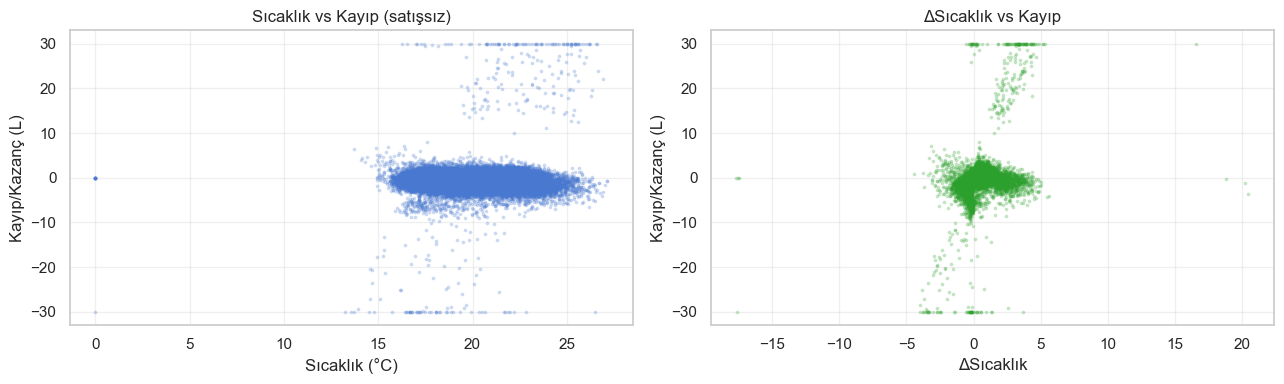

Korelasyon (kayip_kazanc ile):
sicaklik       0.01
dsic           0.09
kayip_kazanc   1.00



=== İstasyon özeti ===


,ort_sicaklik,ort_kayip,satis_toplam
istasyon_kodu,,,
IST_001,20.16,-0.01,"1,392,944.54"
IST_002,20.15,-0.38,"1,411,750.90"
IST_003,20.12,0.24,"783,508.42"
IST_004,20.19,-0.08,"1,340,055.40"
IST_005,20.18,0.55,"801,628.03"
IST_006,20.14,-0.01,"887,830.64"
IST_007,20.19,2.36,"1,182,019.18"
IST_008,20.17,-0.04,"743,249.76"


In [59]:
nosale = ue[(ue.pompa_satis == 0) & ue.sicaklik.notna()].copy()
nosale['dsic'] = nosale.groupby(['istasyon_kodu','tank_no'])['sicaklik'].diff()
sub = nosale.dropna(subset=['dsic'])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(sub['sicaklik'], sub['kayip_kazanc'].clip(-30, 30), s=3, alpha=0.2)
ax[0].set_xlabel('Sıcaklık (°C)'); ax[0].set_ylabel('Kayıp/Kazanç (L)')
ax[0].set_title('Sıcaklık vs Kayıp (satışsız)')
ax[1].scatter(sub['dsic'], sub['kayip_kazanc'].clip(-30, 30), s=3, alpha=0.2, color='tab:green')
ax[1].set_xlabel('ΔSıcaklık'); ax[1].set_ylabel('Kayıp/Kazanç (L)')
ax[1].set_title('ΔSıcaklık vs Kayıp')
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='01_sicaklik_kayip')

corr = sub[['sicaklik','dsic','kayip_kazanc']].corr()['kayip_kazanc']
print('Korelasyon (kayip_kazanc ile):')
print(corr.round(3).to_string())

# İstasyon kırılımında ortalama sıcaklık ve kayıp
ist_ozet = ue.groupby('istasyon_kodu').agg(
    ort_sicaklik=('sicaklik','mean'),
    ort_kayip=('kayip_kazanc','mean'),
    satis_toplam=('pompa_satis','sum'),
).round(2)
print('\n=== İstasyon özeti ===')
display(ist_ozet)


## 2. Kümülatif kayıp trendleri

Sürekli aşağı giden kümülatif eğim = kronik kayıp (statik sızıntı adayı).

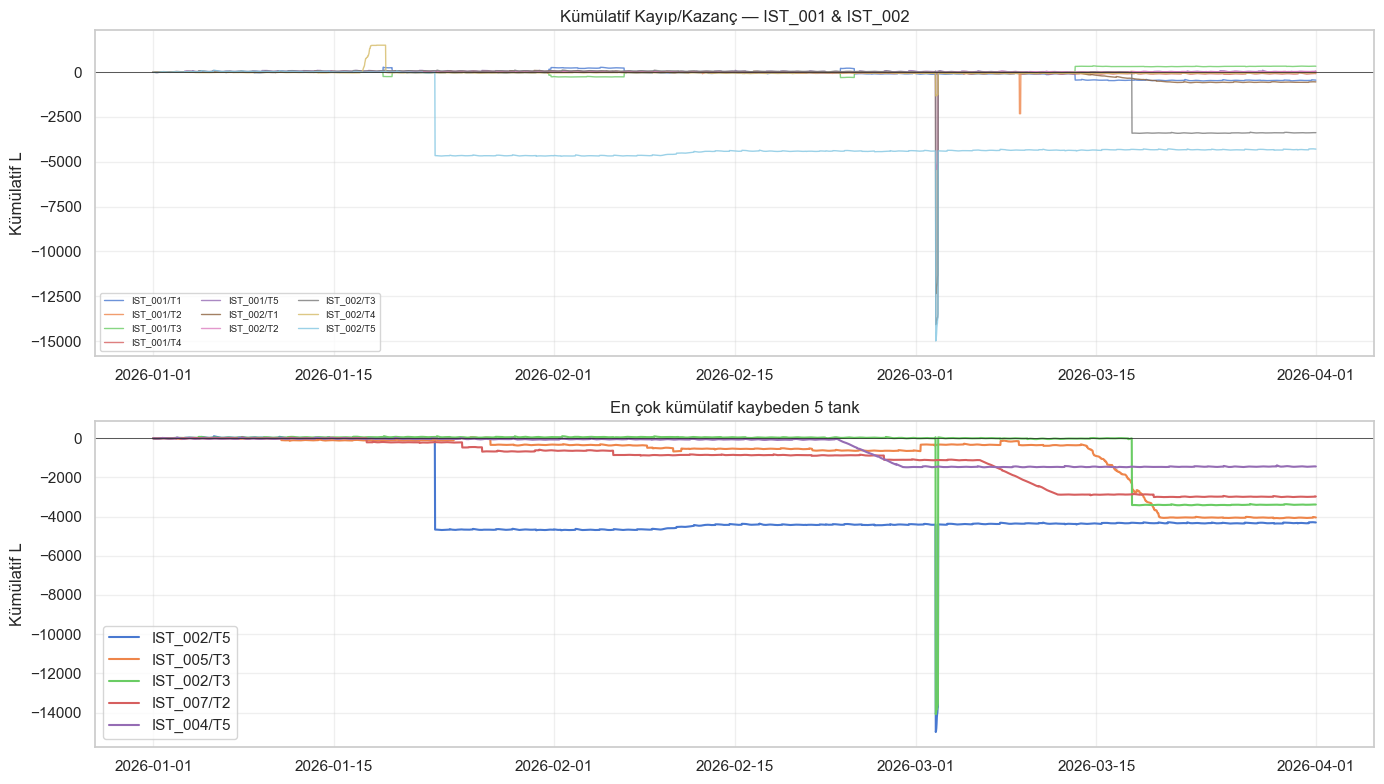

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/02_kumulatif_trend.png')

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# IST_001 ve IST_002 — tüm tanklar
ax = axes[0]
for (st, tk), g in ue.groupby(['istasyon_kodu','tank_no']):
    if st in ('IST_001', 'IST_002'):
        g = g.sort_values('saat_1')
        ax.plot(g['saat_1'], g['kumulatif_kayip_kazanc'], lw=1, label=f'{st}/T{tk}', alpha=0.8)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Kümülatif Kayıp/Kazanç — IST_001 & IST_002')
ax.set_ylabel('Kümülatif L'); ax.legend(fontsize=7, ncol=3)

# En çok kümülatif kaybeden 5 tank
ax = axes[1]
son = ue.sort_values('saat_1').groupby(['istasyon_kodu','tank_no']).last()
top5 = son.nsmallest(5, 'kumulatif_kayip_kazanc')
for (st, tk), _ in top5.iterrows():
    g = ue[(ue.istasyon_kodu==st) & (ue.tank_no==tk)].sort_values('saat_1')
    ax.plot(g['saat_1'], g['kumulatif_kayip_kazanc'], lw=1.5, label=f'{st}/T{tk}')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('En çok kümülatif kaybeden 5 tank')
ax.set_ylabel('Kümülatif L'); ax.legend()
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='02_kumulatif_trend')


## 3. Tanklar arası karşılaştırma

Boxplot + istatistik tablosu — hangi tank daha değişken / daha çok kaybediyor?

=== Tank istatistikleri (tümü) ===


,ort_kayip,std_kayip,min_kum,satis_toplam,satisiz_oran
tank_key,,,,,
IST_002/T5,-0.99,226.32,"-4,297.04","540,500.54",0.18
IST_005/T3,-0.94,12.34,"-4,042.03","287,527.02",0.31
IST_002/T3,-0.78,302.39,"-3,381.65","244,220.23",0.36
IST_007/T2,-0.69,8.53,"-2,971.74","154,459.18",0.36
IST_004/T5,-0.33,3.33,"-1,437.15","275,486.91",0.32
IST_004/T4,-0.31,12.41,"-1,325.66","163,485.26",0.34
IST_003/T1,-0.14,3.38,-595.02,"307,758.08",0.30
IST_002/T1,-0.13,254.35,-549.47,"361,000.57",0.26
IST_001/T1,-0.11,11.62,-453.61,"405,989.93",0.23


,ort_kayip,std_kayip,min_kum,satis_toplam,satisiz_oran
tank_key,,,,,
IST_002/T2,0.01,112.45,45.17,"156,013.71",0.35
IST_001/T5,0.01,4.43,42.72,"492,544.36",0.19
IST_004/T3,0.02,3.68,75.08,"390,107.54",0.24
IST_001/T3,0.07,11.23,322.72,"133,750.80",0.52
IST_007/T4,0.20,98.17,860.70,"159,246.07",0.35
IST_004/T2,0.30,12.38,"1,274.98","154,420.62",0.36
IST_005/T2,0.82,5.78,"3,520.13","96,407.12",0.49
IST_003/T2,0.88,83.78,"3,787.73","305,936.92",0.21
IST_005/T1,1.76,119.46,"7,612.01","417,693.89",0.23


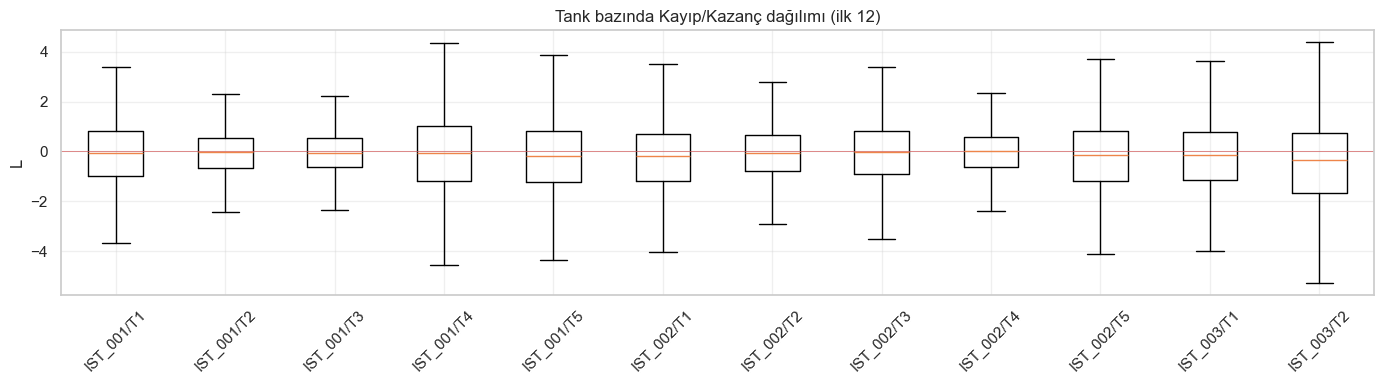

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/03_tank_boxplot.png')

In [61]:
ue['tank_key'] = ue['istasyon_kodu'] + '/T' + ue['tank_no'].astype(str)

tank_stats = ue.groupby('tank_key').agg(
    ort_kayip=('kayip_kazanc','mean'),
    std_kayip=('kayip_kazanc','std'),
    min_kum=('kumulatif_kayip_kazanc','last'),
    satis_toplam=('pompa_satis','sum'),
    satisiz_oran=('pompa_satis', lambda x: (x==0).mean()),
).round(2)
print('=== Tank istatistikleri (tümü) ===')
display(tank_stats.sort_values('ort_kayip').head(10))
display(tank_stats.sort_values('ort_kayip').tail(10))

keys = ue['tank_key'].unique()[:12]
data = [ue[ue.tank_key==k]['kayip_kazanc'].clip(-40, 40).values for k in keys]
fig, ax = plt.subplots(figsize=(14, 4))
ax.boxplot(data, tick_labels=keys, showfliers=False)
ax.axhline(0, color='r', lw=0.5)
ax.set_title('Tank bazında Kayıp/Kazanç dağılımı (ilk 12)')
ax.set_ylabel('L'); plt.xticks(rotation=45)
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='03_tank_boxplot')


## 4. Manifold çifti analizi

Manifold bağlı tanklarda ters yönlü kayıp/kazanç beklenir (check-valve kaçırması).

Manifold tanklar:


,istasyon_kodu,tank_no,manifold_grup_no,akaryakit_turu
0,IST_001,1,1,Motorin(Excellium)
2,IST_001,3,1,Motorin(Excellium)
14,IST_004,2,1,KB 95 Oktan Excellium
16,IST_004,4,1,KB 95 Oktan Excellium
18,IST_005,1,1,Motorin(Excellium)
20,IST_005,3,1,Motorin(Excellium)
26,IST_007,2,1,KB 95 Oktan Excellium
28,IST_007,4,1,KB 95 Oktan Excellium



=== Manifold çift korelasyonları ===


,istasyon,grup,tank_a,tank_b,kk_korelasyon,n_donem
0,IST_001,1,1,3,-0.94,4320
1,IST_004,1,2,4,-0.96,4320
2,IST_005,1,1,3,-0.07,4318
3,IST_007,1,2,4,-0.07,4310


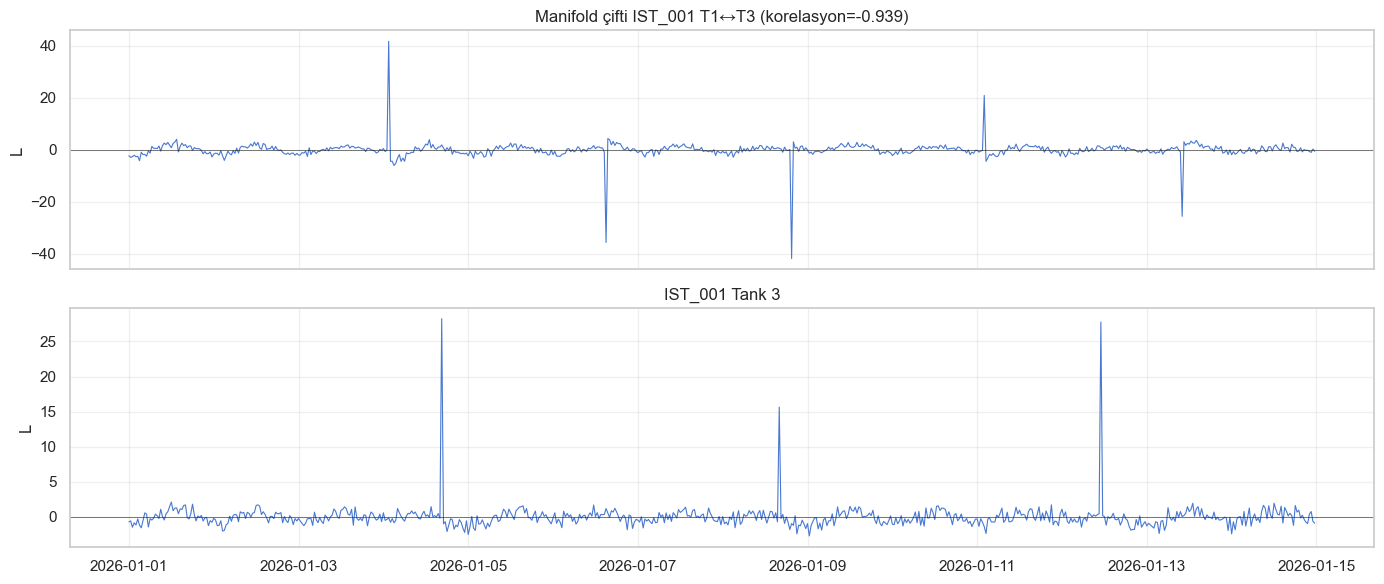

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/04_manifold_cift.png')

In [62]:
man = tanks[tanks.is_manifold == 1][['istasyon_kodu','tank_no','manifold_grup_no','akaryakit_turu']]
print('Manifold tanklar:')
display(man)

# Tüm çiftler için korelasyon tablosu
pairs = []
for (ist, mg), g in man.groupby(['istasyon_kodu','manifold_grup_no']):
    tn = sorted(g['tank_no'].tolist())
    if len(tn) == 2:
        a, b = tn
        ua = ue[(ue.istasyon_kodu==ist)&(ue.tank_no==a)].set_index('saat_1')['kayip_kazanc']
        ub = ue[(ue.istasyon_kodu==ist)&(ue.tank_no==b)].set_index('saat_1')['kayip_kazanc']
        m = pd.concat([ua, ub], axis=1, keys=['a','b']).dropna()
        corr = m['a'].corr(m['b']) if len(m) > 50 else np.nan
        pairs.append({'istasyon': ist, 'grup': mg, 'tank_a': a, 'tank_b': b,
                      'kk_korelasyon': round(corr, 3), 'n_donem': len(m)})
pair_df = pd.DataFrame(pairs)
print('\n=== Manifold çift korelasyonları ===')
display(pair_df)

# İlk çift — zaman serisi
st, mg = pair_df.iloc[0]['istasyon'], pair_df.iloc[0]['grup']
ta, tb = int(pair_df.iloc[0]['tank_a']), int(pair_df.iloc[0]['tank_b'])
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for tk, ax in zip([ta, tb], axes):
    g = ue[(ue.istasyon_kodu==st)&(ue.tank_no==tk)].sort_values('saat_1').iloc[:48*14]
    ax.plot(g['saat_1'], g['kayip_kazanc'], lw=0.8)
    ax.axhline(0, color='k', lw=0.4)
    ax.set_ylabel('L'); ax.set_title(f'{st} Tank {tk}')
axes[0].set_title(f'Manifold çifti {st} T{ta}↔T{tb} (korelasyon={pair_df.iloc[0]["kk_korelasyon"]})')
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='04_manifold_cift')


## 5. Null / eksik veri kümelenmesi

Null'lar rastgele değil — probe arızası, router gecikmesi, mapping hatası senaryoları.

In [63]:
# Null matrisi — tüm tablolar
null_rows = []
for name, df in dfs.items():
    for col in df.columns:
        n = df[col].isna().sum()
        if n:
            null_rows.append({'tablo': name, 'kolon': col, 'null': n,
                              'oran_pct': round(100*n/len(df), 2)})
null_df = pd.DataFrame(null_rows).sort_values('null', ascending=False)
print('=== Null özeti (tüm tablolar) ===')
display(null_df.head(15))

# Sıcaklık null — tank × gün kümesi
tmp = ue.copy()
tmp['gun'] = tmp['saat_1'].dt.date
tmp['sic_null'] = tmp['sicaklik'].isna()
sic_pivot = tmp.groupby(['istasyon_kodu','tank_no'])['sic_null'].sum()
print('\nSıcaklık NaN (tank, >0):')
print(sic_pivot[sic_pivot > 0].to_string())

# Merkeze geliş gecikmesi
inv2 = inv.dropna(subset=['merkeze_gelis_tarihi']).copy()
inv2['gecikme_dk'] = (inv2['merkeze_gelis_tarihi'] - inv2['envanter_tarihi']).dt.total_seconds() / 60
print('\nGecikme istatistikleri (dk):')
print(inv2['gecikme_dk'].describe().round(1).to_string())


=== Null özeti (tüm tablolar) ===


,tablo,kolon,null,oran_pct
1,transactions,tank_no,2548,1.10
3,transactions,birim_fiyat,927,0.40
2,transactions,litre,463,0.20
13,ue1t_30min,baslangic_seviyesi_cm,414,0.30
11,inventory_30min,merkeze_gelis_tarihi,276,0.20
7,inventory_30min,urun_miktari_net,240,0.17
10,inventory_30min,sicaklik,240,0.17
12,ue1t_30min,sicaklik,240,0.17
6,deliveries,merkeze_gelis_tarihi,170,15.33
5,deliveries,sicaklik,109,9.83



Sıcaklık NaN (tank, >0):
istasyon_kodu  tank_no
IST_002        1          48
               4          48
IST_003        1          48
               3          48
IST_008        2          48

Gecikme istatistikleri (dk):
count   137,918.00
mean          7.10
std          35.20
min           1.00
25%           4.00
50%           6.00
75%           8.00
max       1,795.80


## 6. Günlük ↔ 30 dk rollup

`daily.fark` ile UE1T 30 dk kayıp/kazanç toplamının aynı günde tutarlı olup olmadığı.

=== Günlük fark vs UE1T kk toplam ===
           fark  ue1t_kk_toplam  fark_ue1t_fark
count  2,880.00        2,880.00        2,880.00
mean      13.89           13.89            0.00
std      849.34          849.34            0.00
min   -4,623.45       -4,623.45           -0.00
25%       -8.23           -8.23           -0.00
50%       -0.58           -0.58            0.00
75%        7.35            7.35            0.00
max   43,121.62       43,121.62            0.00

Max |fark - ue1t_kk|: 0.00 L

Ort. fark — alarm vs normal:
       count   mean      std
alarm                       
0       2709  -0.35    12.63
1        171 239.40 3,487.08


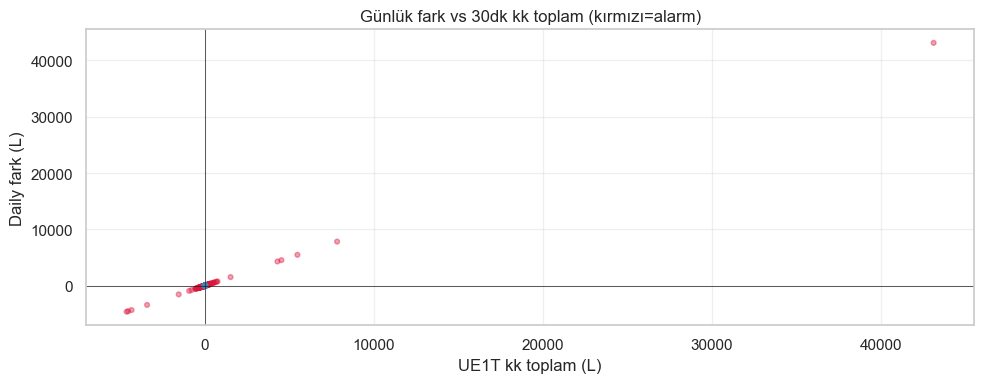

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/06_daily_ue1t_rollup.png')

In [64]:
ue['tarih'] = ue['saat_1'].dt.normalize()
ue_gun = ue.groupby(['istasyon_kodu','tank_no','tarih'], as_index=False).agg(
    ue1t_kk_toplam=('kayip_kazanc','sum'),
    ue1t_satis=('pompa_satis','sum'),
    ue1t_dolum=('tanka_dolum','sum'),
)
m = daily.merge(ue_gun, on=['istasyon_kodu','tank_no','tarih'], how='left')
m['fark_ue1t_fark'] = m['fark'] - m['ue1t_kk_toplam']

print('=== Günlük fark vs UE1T kk toplam ===')
print(m[['fark','ue1t_kk_toplam','fark_ue1t_fark']].describe().round(2).to_string())
print(f'\nMax |fark - ue1t_kk|: {m["fark_ue1t_fark"].abs().max():.2f} L')

# Alarm günleri vs normal
print('\nOrt. fark — alarm vs normal:')
print(m.groupby('alarm')['fark'].agg(['count','mean','std']).round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
colors = m['alarm'].map({0:'steelblue', 1:'crimson'})
ax.scatter(m['ue1t_kk_toplam'], m['fark'], c=colors, alpha=0.4, s=12)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('UE1T kk toplam (L)'); ax.set_ylabel('Daily fark (L)')
ax.set_title('Günlük fark vs 30dk kk toplam (kırmızı=alarm)')
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='06_daily_ue1t_rollup')


## 7. Saat × haftanın günü heatmap

Kayıp/kazancın hangi saat ve günde yoğunlaştığını görürüz (manipülasyon / gece deseni).

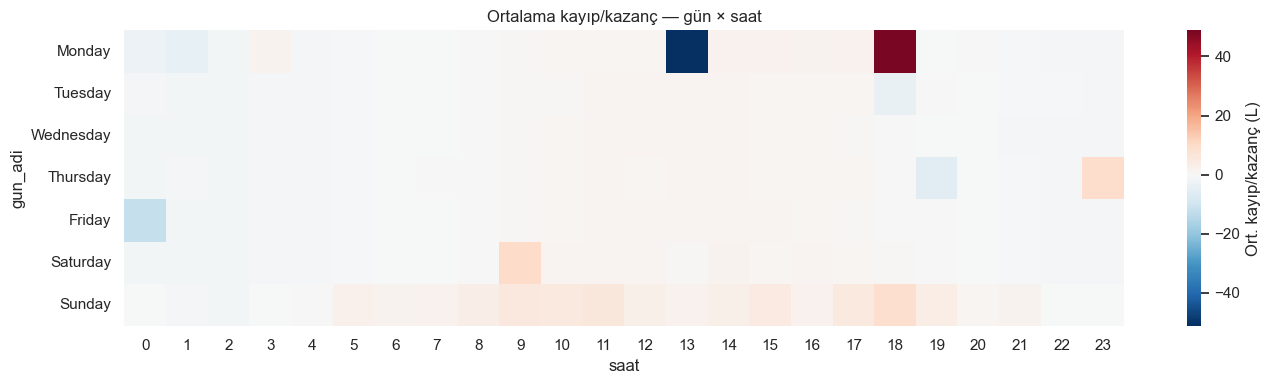


Gece vs gündüz kayıp/kazanç:
       count  mean    std
gece                     
0     103640  0.82 105.31
1      34554 -1.29  41.72


In [65]:
ue['saat'] = ue['saat_1'].dt.hour
ue['haftanin_gunu'] = ue['saat_1'].dt.dayofweek
ue['gun_adi'] = ue['saat_1'].dt.day_name()

heat = ue.pivot_table(
    index='gun_adi', columns='saat', values='kayip_kazanc', aggfunc='mean'
)
gun_sira = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat = heat.reindex([g for g in gun_sira if g in heat.index])

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heat, cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'Ort. kayıp/kazanç (L)'})
ax.set_title('Ortalama kayıp/kazanç — gün × saat')
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='07_heatmap_gun_saat')

# Gece vs gündüz özet
ue['gece'] = ue['saat'].between(0, 5).astype(int)
print('\nGece vs gündüz kayıp/kazanç:')
print(ue.groupby('gece')['kayip_kazanc'].agg(['count','mean','std']).round(2).to_string())


## 8. Dolum sonrası kayıp/kazanç

Dolum olaylarından sonraki 6 saatlik pencerede anormal kayıp var mı? (hayali/algılanmayan dolum).

Dolum eşleşen UE1T dönem: 1,109

Dolum anı kayıp/kazanç istatistikleri:
count    1,109.00
mean        16.60
std        268.48
min     -4,649.26
25%        -12.44
50%         23.17
75%         33.66
max      4,531.92

=== En büyük 5 dolum ===


,dolum_baslangic,istasyon_kodu,tank_no,dolum_net,dolum_oncesi_hacim,dolum_sonrasi_hacim
634,2026-01-02 18:36:00,IST_005,3,"12,994.52","5,503.85","18,498.37"
890,2026-01-20 17:03:00,IST_007,1,"12,981.96",NaN,"18,556.15"
686,2026-02-16 15:37:00,IST_005,1,"12,979.52","5,525.83","18,505.35"
54,2026-01-28 10:41:00,IST_001,5,"12,972.47","7,531.81","20,504.28"
940,2026-02-18 19:08:00,IST_007,1,"12,966.21",NaN,"18,396.83"


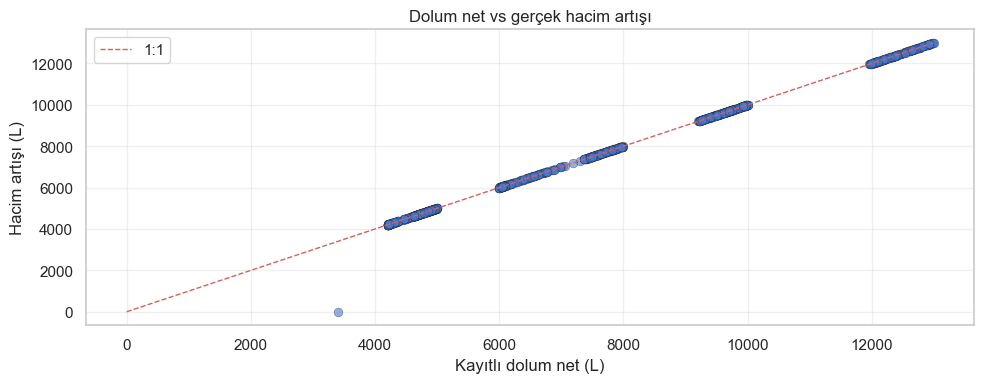

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/08_dolum_analizi.png')

In [66]:
# Dolum zamanlarını UE1T ile eşleştir
deliv2 = deliv.copy()
deliv2['dolum_saat'] = deliv2['dolum_baslangic'].dt.floor('30min')

dolum_donem = ue.merge(
    deliv2[['istasyon_kodu','tank_no','dolum_saat','dolum_net']],
    left_on=['istasyon_kodu','tank_no','saat_1'],
    right_on=['istasyon_kodu','tank_no','dolum_saat'],
    how='inner',
)
print(f'Dolum eşleşen UE1T dönem: {len(dolum_donem):,}')
print('\nDolum anı kayıp/kazanç istatistikleri:')
print(dolum_donem['kayip_kazanc'].describe().round(2).to_string())

# En büyük 5 dolum
top_dolum = deliv.nlargest(5, 'dolum_net')
print('\n=== En büyük 5 dolum ===')
display(top_dolum[['dolum_baslangic','istasyon_kodu','tank_no','dolum_net','dolum_oncesi_hacim','dolum_sonrasi_hacim']])

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(deliv['dolum_net'], deliv['dolum_sonrasi_hacim'] - deliv['dolum_oncesi_hacim'],
           alpha=0.6, s=40, edgecolors='k', linewidths=0.3)
ax.plot([0, deliv['dolum_net'].max()], [0, deliv['dolum_net'].max()], 'r--', lw=1, label='1:1')
ax.set_xlabel('Kayıtlı dolum net (L)'); ax.set_ylabel('Hacim artışı (L)')
ax.set_title('Dolum net vs gerçek hacim artışı')
ax.legend(); plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='08_dolum_analizi')


## 9. Envanter katmanı — su ve brüt/net

UE1T + envanter join ile su sıçraması ve sıcaklık kompanzasyonu.

IST_001 T1 join satır: 4,320

Brüt-net fark: count   4,320.00
mean       40.40
std        21.60
min         0.13
25%        24.33
50%        37.12
75%        51.61
max       152.02

Su sıçrama (>0.05 cm): 0


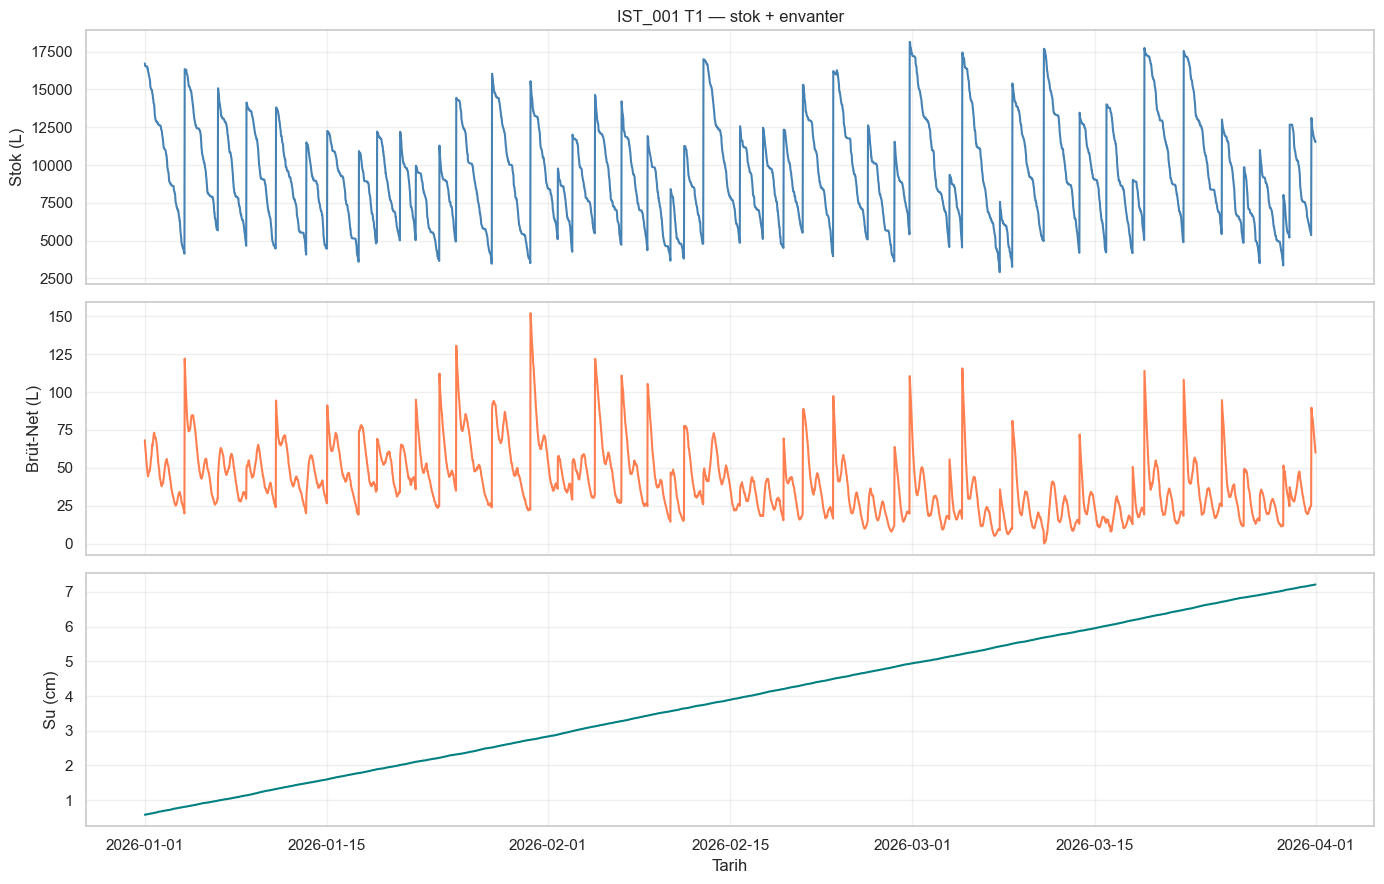

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/09_envanter_join.png')

In [67]:
IST, TANK = 'IST_001', 1
merged = merge_ue1t_inventory(
    filter_tank(ue, IST, TANK),
    filter_tank(inv, IST, TANK),
)
merged = merged.sort_values('saat_1')
merged['brut_net_fark'] = merged['urun_miktari_brut'] - merged['urun_miktari_net']
merged['su_diff'] = merged.groupby(['istasyon_kodu','tank_no'])['su_seviyesi_cm'].diff()

print(f'{IST} T{TANK} join satır: {len(merged):,}')
print('\nBrüt-net fark:', merged['brut_net_fark'].describe().round(2).to_string())
print('\nSu sıçrama (>0.05 cm):', (merged['su_diff'] > 0.05).sum())

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(merged['saat_1'], merged['donem_sonu_stok'], color='steelblue')
axes[0].set_ylabel('Stok (L)'); axes[0].set_title(f'{IST} T{TANK} — stok + envanter')
axes[1].plot(merged['saat_1'], merged['brut_net_fark'], color='coral')
axes[1].set_ylabel('Brüt-Net (L)')
axes[2].plot(merged['saat_1'], merged['su_seviyesi_cm'].fillna(0), color='teal')
axes[2].set_ylabel('Su (cm)'); axes[2].set_xlabel('Tarih')
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='09_envanter_join')


## 10. Unmapped satış analizi

`tank_no` null satışlar — mapping hatası; katman tutarlılığını etkiler.

In [68]:
unmapped = tx[tx['tank_no'].isna()]
mapped   = tx[tx['tank_no'].notna()]
print(f'Unmapped işlem : {len(unmapped):,} ({100*len(unmapped)/len(tx):.2f}%)')
print(f'Unmapped litre : {unmapped["litre"].sum():,.1f} L')
print(f'Mapped litre   : {mapped["litre"].sum():,.1f} L')

print('\n=== Unmapped — istasyon kırılımı ===')
display(unmapped.groupby('istasyon_kodu').agg(
    islem=('litre','count'), litre=('litre','sum')
).sort_values('litre', ascending=False))

# TX vs UE1T fark özeti
checks = run_all_checks(dfs)
txu = checks['tx_to_ue1t']
print('\n=== TX↔UE1T fark özeti ===')
print(f'Uyuşmayan dönem: {(txu["tx_ue1t_fark"].abs() > 0.01).sum():,}')
print(txu['tx_ue1t_fark'].describe().round(2).to_string())


Unmapped işlem : 2,548 (1.10%)
Unmapped litre : 93,008.1 L
Mapped litre   : 8,433,509.4 L

=== Unmapped — istasyon kırılımı ===


,islem,litre
istasyon_kodu,,
IST_004,418,"15,477.97"
IST_001,381,"13,969.06"
IST_002,369,"13,875.41"
IST_007,337,"12,618.15"
IST_006,330,"10,956.76"
IST_008,223,"8,891.62"
IST_003,265,"8,758.46"
IST_005,222,"8,460.64"



=== TX↔UE1T fark özeti ===
Uyuşmayan dönem: 2,941
count   138,194.00
mean          0.79
std           6.65
min          -0.00
25%           0.00
50%           0.00
75%           0.00
max         214.01


## 11. Alarm günü 30 dk profili

SEL alarmı olan günlerde 30 dk kayıp/kazanç nasıl dağılıyor?

Alarm gün-tank: 171  (oran: 5.9%)

=== En yüksek |fark| alarm günleri ===


,tarih,istasyon_kodu,tank_no,fark,satis,sel,alarm
2316,2026-03-08,IST_007,1,"43,121.62","47,893.20",263.47,1
1636,2026-01-17,IST_005,1,"7,830.29","4,867.86",48.34,1
1056,2026-03-08,IST_003,2,"5,481.74","3,530.53",41.65,1


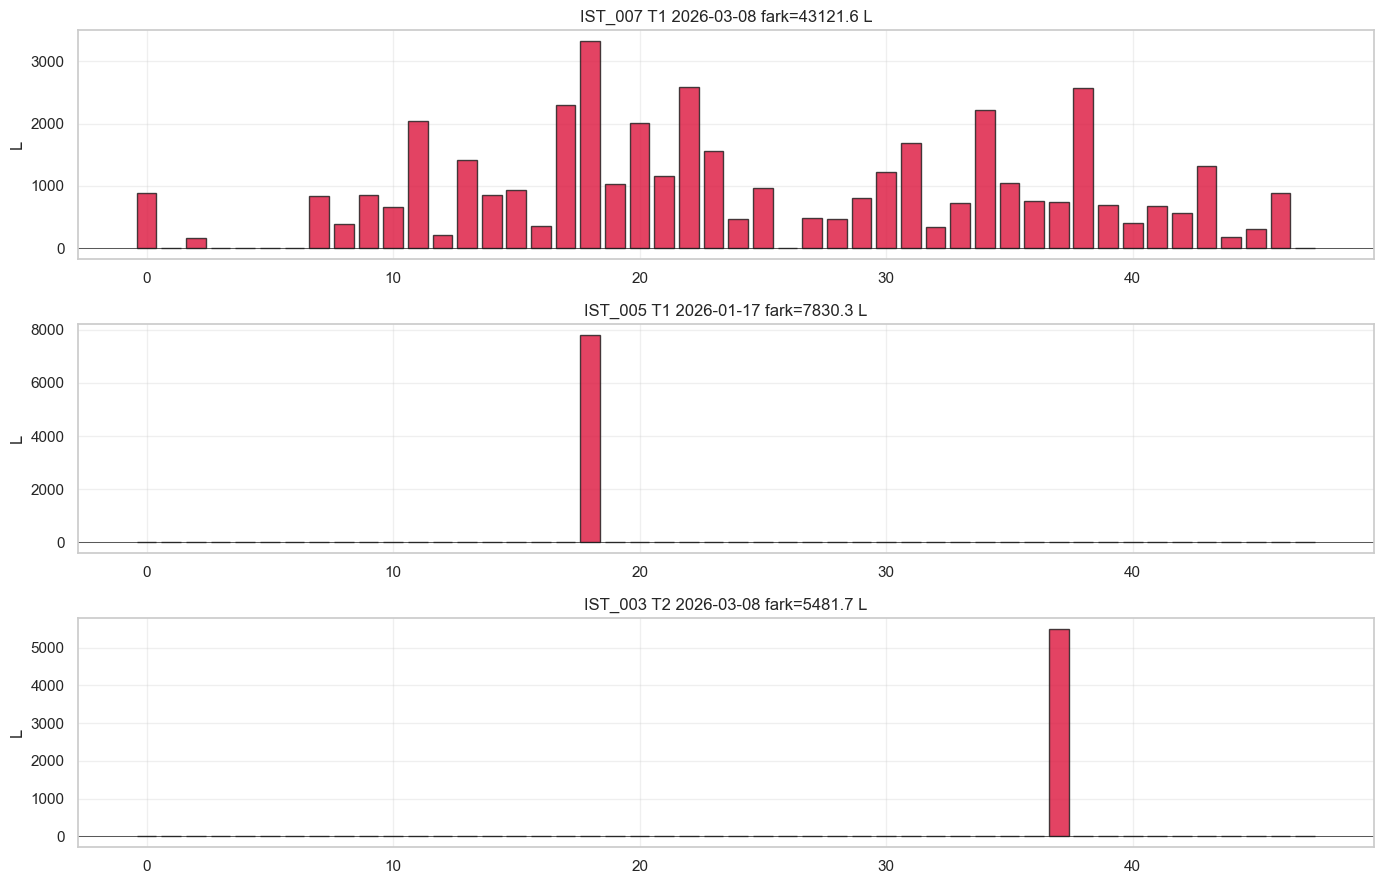

PosixPath('/Users/mangtay/Desktop/Staj/eda/output/figures/10_deep_eda/11_alarm_gun_profil.png')

In [69]:
alarm_gunler = daily[daily['alarm'] == 1].copy()
print(f'Alarm gün-tank: {len(alarm_gunler):,}  (oran: {daily["alarm"].mean():.1%})')

# En yüksek |fark| 3 alarm günü
top_alarm = alarm_gunler.assign(fark_abs=alarm_gunler['fark'].abs()).nlargest(3, 'fark_abs')
print('\n=== En yüksek |fark| alarm günleri ===')
display(top_alarm[['tarih','istasyon_kodu','tank_no','fark','satis','sel','alarm']])

fig, axes = plt.subplots(len(top_alarm), 1, figsize=(14, 3*len(top_alarm)), sharex=False)
if len(top_alarm) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, top_alarm.iterrows()):
    u = ue[(ue.istasyon_kodu==row.istasyon_kodu) & (ue.tank_no==row.tank_no)
           & (ue['tarih']==row.tarih)]
    ax.bar(range(len(u)), u['kayip_kazanc'], color='crimson', edgecolor='k', alpha=0.8)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('L')
    ax.set_title(f'{row.istasyon_kodu} T{row.tank_no} {row.tarih.date()} fark={row.fark:.1f} L')
plt.tight_layout()
set_section('10_deep_eda'); save_fig(name='11_alarm_gun_profil')


## 12. Tank risk özeti tablosu

Her tank için birleşik metrikler — FE ve ML öncesi önceliklendirme.

In [70]:
# Tank meta + UE1T + daily rollup
ue2 = ue.copy()
ue2['satisiz_kayip_flag'] = ((ue2['pompa_satis'] == 0) & (ue2['kayip_kazanc'] < -5)).astype(int)

tank_risk = ue2.groupby(['istasyon_kodu','tank_no']).agg(
    ort_kayip=('kayip_kazanc','mean'),
    std_kayip=('kayip_kazanc','std'),
    satisiz_kayip=('satisiz_kayip_flag','sum'),
    kum_son=('kumulatif_kayip_kazanc','last'),
    sic_null=('sicaklik', lambda x: x.isna().sum()),
).reset_index()

alarm_cnt = daily.groupby(['istasyon_kodu','tank_no'])['alarm'].sum().reset_index(name='alarm_gun')
tank_risk = tank_risk.merge(alarm_cnt, on=['istasyon_kodu','tank_no'], how='left')
tank_risk = tank_risk.merge(
    tanks[['istasyon_kodu','tank_no','kapasite','akaryakit_turu','is_manifold','bolmeli']],
    on=['istasyon_kodu','tank_no'], how='left',
)
tank_risk['tank_key'] = tank_risk['istasyon_kodu'] + '/T' + tank_risk['tank_no'].astype(str)

print('=== Tank risk tablosu (en çok alarm) ===')
display(tank_risk.sort_values('alarm_gun', ascending=False).head(10))

print('\n=== Tank risk tablosu (en çok kümülatif kayıp) ===')
display(tank_risk.nsmallest(5, 'kum_son')[['tank_key','ort_kayip','kum_son','alarm_gun','is_manifold','akaryakit_turu']])

# Kaydet
out = ROOT / 'output' / 'tank_risk_ozet.csv'
out.parent.mkdir(parents=True, exist_ok=True)
tank_risk.to_csv(out, index=False)
print(f'\nKaydedildi: {out}')


=== Tank risk tablosu (en çok alarm) ===


,istasyon_kodu,tank_no,ort_kayip,std_kayip,satisiz_kayip,kum_son,sic_null,alarm_gun,kapasite,akaryakit_turu,is_manifold,bolmeli,tank_key
11,IST_003,2,0.88,83.78,34,"3,787.73",0,16,20000,KB 95 Oktan Excellium,0,1,IST_003/T2
20,IST_005,3,-0.94,12.34,36,"-4,042.03",0,15,23000,Motorin(Excellium),1,0,IST_005/T3
18,IST_005,1,1.76,119.46,6,"7,612.01",0,15,23000,Motorin(Excellium),1,0,IST_005/T1
26,IST_007,2,-0.69,8.53,89,"-2,971.74",0,14,10000,KB 95 Oktan Excellium,1,0,IST_007/T2
28,IST_007,4,0.20,98.17,5,860.70,0,10,10000,KB 95 Oktan Excellium,1,0,IST_007/T4
16,IST_004,4,-0.31,12.41,4,"-1,325.66",0,9,10000,KB 95 Oktan Excellium,1,0,IST_004/T4
14,IST_004,2,0.30,12.38,3,"1,274.98",0,9,10000,KB 95 Oktan Excellium,1,0,IST_004/T2
10,IST_003,1,-0.14,3.38,5,-595.02,48,8,23000,Motorin(Excellium),0,0,IST_003/T1
5,IST_002,1,-0.13,254.35,4,-549.47,48,8,23000,Motorin(Excellium),0,0,IST_002/T1
17,IST_004,5,-0.33,3.33,72,"-1,437.15",0,7,20000,Motorin(Excellium),0,0,IST_004/T5



=== Tank risk tablosu (en çok kümülatif kayıp) ===


,tank_key,ort_kayip,kum_son,alarm_gun,is_manifold,akaryakit_turu
9,IST_002/T5,-0.99,"-4,297.04",4,0,Motorin(Excellium)
20,IST_005/T3,-0.94,"-4,042.03",15,1,Motorin(Excellium)
7,IST_002/T3,-0.78,"-3,381.65",3,0,Motorin(Excellium)
26,IST_007/T2,-0.69,"-2,971.74",14,1,KB 95 Oktan Excellium
17,IST_004/T5,-0.33,"-1,437.15",7,0,Motorin(Excellium)



Kaydedildi: /Users/mangtay/Desktop/Staj/eda/output/tank_risk_ozet.csv


## Gün 7 Özeti

| Bölüm | Bulgu |
|-------|-------|
| Veri envanteri | 8 tablo, 90 gün, 32 tank — yıldız şeması tutarlı |
| Sıcaklık | Satışsız dönemde korelasyon zayıf → termal/sızıntı ayrımı mümkün |
| Kümülatif trend | Kronik kaybeden tanklar belirlendi |
| Manifold | Çiftlerde kk korelasyon ≈ -0.94 (ters yön) |
| Null | Sıcaklık null'ları tank-gün kümesi (probe arızası) |
| Daily↔UE1T | Alarm günlerinde fark profili farklı |
| Heatmap | Gece saatlerinde kayıp deseni |
| Dolum | Dolum anı ve hacim artışı karşılaştırması |
| Envanter | Brüt-net fark, su seviyesi join |
| Unmapped TX | ~%1.1 işlem, mapping hatası sinyali |
| Alarm profili | SEL aşım günlerinde 30dk bar grafik |
| Tank risk | `output/tank_risk_ozet.csv` — ML öncesi öncelik listesi |

**Sonraki adım:** Gün 8 Feature Engineering (`feature_engineering/notebooks/GUN08_feature_engineering.ipynb`)
